# 2DMRFs Models code by Giorgos Romporas 2025-2026


### SP_S2/4 MODELS
for the validation of the actual parameters of the connections after the fitting its useful to simulate backwards within the setup parameters to validate the results first before doing the non linear dynamic simulations and comparison with the test data 



## Units
Units KN m Kpa in  direct input to opensees.
Units have to be adjusted per literature for functions component models and regression models such as: Lignos 2013 for beam PH,Elkady,Hartloper 2019 for colmns PH,Krawinkler Skiadakopoulos Kim etc for panel zone and any and all functions that produce backbone curves through either hysteric or IMK models. 
## Output 
recorders and plots can be tunned further especially in tcl as the recorders do not work currently for openseespy 
## Workflow 
Installing the correct version of py and if needs be creating a seperate env    
Intalling  the various packages avoiding dependency hell either through requirements.txt through a terminal running on the py version running opensees compatible -v
Importing packages in the main  
Importing sections from database selected   
Creating model command and Gridops grid object (can be created by cad txt polyline input or by seperate mesher )    
UVC Steel  uniaxial material command via Hartloper  
Creation  of fiber section (should be replaced for fliping axes or other section type than I,for 3d the rotation can be acvieved through Geotransormation command , see opensees wiki for more information )    
Sourcing and calculating Elkady Extended endplate backbone curve , option for manual input also for comparison      
Sourcing spring IMK script creating PH on beams and cols based on Lignos 2013 and Elkady 2016 ,Hartloper 2019   
Sourcing and constructing Panelzones based on framework for Panelzone Krawinkler one rotational spring models (no scissors) 
Sourcing eqdof script assigning eq dof based on the tag of the zero length eles     
Sourcing and Calculating PZ Springs via Krawinlker , Skiadakopoulos ,Manual , Kim   
Building model  
Gravity analysis for constant time , for more on timeseries see opensees wiki   
Cyclic analysis , (other analysis options inside folder might need tunning and can not be runned arbitarilly)   
Output options and Control Panel plots  


# 1 Intallation and requirements 
### Notes for devs
Notes on dependencies: opensees uses python as an interpreter/API all the source code is still in c and called through tcl as core functions of the package 
Opensees needs py-V 3.12 or greater calling opensees scripts  is no longer supported as they have to not include tcl language either calculations as there are no wheels for 3.10 and counting this means that previous tcl sourced files can not be called and especially proc self defined and not impilmented in the main SRC as construct panel for example 
when creating the enviroment one works with dependencies eurocodes and structuralcodes structural codes is more robust and supported by fib. Structural codes is compilled in numpy 1 so its commented out as numpa does not work with numpa lower than 2 ,
its a matter of comvienience structural codes has a lot possibilitites especially for concrete mats and sections but not quite easilly accessible documentation man has to go through 

In [1]:
#######ENVIROMENT SETUP - INSTALLATIONS#######################
#Running from terminal requirements
#pip install -r requirements.txt
#pip list
import openpyxl#import lib
from openpyxl import Workbook
from openpyxl import load_workbook
import defusedxml
print(defusedxml.__version__)
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import openseespy.opensees as ops
import sys
import eurocodepy as ec
import opsvis as opsv 
print('Packaging_Complete if there is an error see Reedme and run req.txt')
import os
import shutil

MainFolder = "ResultsMainFolder"
SubFolder  = "ResultsSubFolder_SPS2"

MainPath = os.path.join(os.getcwd(), MainFolder)
SubPath  = os.path.join(MainPath, SubFolder)

# Remove old results to avoid mixing runs (optional but recommended)
if os.path.exists(SubPath):
    shutil.rmtree(SubPath)

# Create folders
os.makedirs(SubPath, exist_ok=True)

print("Results will be written to:", SubPath)


0.7.1
Packaging_Complete if there is an error see Reedme and run req.txt
Results will be written to: c:\Users\giorg\Desktop\RWTH Aachen\Hardwired\RobThesis\ResultsMainFolder\ResultsSubFolder_SPS2


# 2 Grid generation - Sections import
Import of database and functions for manipulating the Section Properties    
Assigning Connection type for Plastic Hinge Offset from connestion based on its type for more information see the Beam Section in the Thesis    
Mass values assigned important for dynamic analysis not used in Cyclic Besides gravity loads
 

In [2]:
############## GRID - SECTION - LOAD GEOMETRY SETUP ##############
#pip install structuralcodes 
#from structuralcodes.geometry import SurfaceGeometry
#from structuralcodes.geometry.profiles import IPE
#from structuralcodes.geometry.profiles import HE
#IPE.profiles()
#HE.profiles()
#accesss database of the sourcecode
db = ec.db
#nodes and grid cretion
ops.wipe() #wipes all results var and preexisting
ndm=2#number of dimmensions
ndf=3#number of dofs
ops.model('basic','-ndm',ndm,'-ndf',ndf)
#tStart=ops.clock
negl=np.exp(1^-9)
m=1
#the database needs this workaround in order to have the sections with atrributes unlike stucturalcodes 
#so before the initialahzation choose the Sections in this section
#CONTROL 
def section_to_mm(sec):
    sec_mm = sec.copy()
    
    # length [cm → mm]
    for k in ["h", "b", "tw", "tf", "r", "iy", "iz"]:
        sec_mm[k] *= 10.0
    # area [cm² → mm²]
    for k in ["A", "Av_y", "Av_z"]:
        sec_mm[k] *= 100.0
    # inertia [cm⁴ → mm⁴]
    for k in ["Iy", "Iz", "IT"]:
        sec_mm[k] *= 1e4
    # section modulus [cm³ → mm³]
    for k in ["Wel_y", "Wel_z", "Wpl_y", "Wpl_z", "WT"]:
        sec_mm[k] *= 1e3
    # warping constant [cm⁶ → mm⁶]
    sec_mm["Iw"] *= 1e6
    return sec_mm
def find_section(db, family, name):
    for p in db["SteelProfiles"][family]:
        if p.get("Section") == name:
            return section_to_mm(p)
    return None

ipe200 = find_section(ec.db, "EuroI", "IPE200")
ipe160 = find_section(ec.db, "EuroI", "IPE160")
hea160 = find_section(ec.db, "EuroI", "HEA160")
hea200 = find_section(ec.db, "EuroI", "HEA200")
hea240 = find_section(ec.db, "EuroI", "HEA240")
hea300 = find_section(ec.db, "EuroI", "HEA300")
heb300 = find_section(ec.db, "EuroI", "HEB300")
if ipe200 is None:
    print("Section IPE200 not found")
else:
    print(ipe200)#control
print(ipe200["h"])
class Sectionatr:
    def __init__(self, d):
        for k, v in d.items():
            setattr(self, k, v)

SecbeamX=Sectionatr(hea240)
SecbeamY=Sectionatr(ipe160)
SecColmn=Sectionatr(heb300)
SecBeamActuator=Sectionatr(heb300)
print('Act m ',SecBeamActuator.m)
class Section:
    def __init__(self, d):
        for k, v in d.items():
            setattr(self, k, v)
#SecbeamX=Section(ipe200)
SecbeamX.h #units in the list mm,
Unitsmulti=0.001
#opensees has no units section so everything must be in the same category with their 
#respective calcs in order to arrive at normal results some functions have hard caps 
#meaning you can not work with every unit per say 
#Note grid generator can support different versions and setups the currewnt script functions with the setup of the notation as in the appedix and the drawings
#also gid can be employed and or different kind of meshers 
Pdetla_lean_on=False #option to include gravity equivilent frames and lean on columns to induce P-Delta effects including the Non Load Bearing secondary elements internal partitions etc
#for more accurate Performance based design see elghazouli on super dead load multiplier for steel structures 
class grid:
    def __init__(self):
            self.nHbays=2
            self.nXbays=2
            if Pdetla_lean_on==True:
                 self.nXbays=self.nHbays+1
            self.Xbay_stval=5*m   #center line to center line
            self.Ybay_stval=2.4*m   #center line to center line 
            self.Hbay_stval=1.4*m  #lop floor fiber as per drawings in report
            self.Xnodes= np.linspace(0, self.nXbays*self.Xbay_stval, self.nXbays+1)#better option for auto
            #self.Xnodes=np.array(CAD,DATAEXTRACT) or PL&LIST 
            self.Ynodes= np.linspace(0, self.nHbays*self.Hbay_stval, self.nHbays+1)
            #further refinery SecBeam per floor might be different arrange an array with floor data such as numberer/level and 
            #self.Ynodes=self.Ynodes+np.array([0,-SecbeamX.h*Unitsmulti,-SecbeamX.h*Unitsmulti-0.26])
            #self.Ynodes=np.array([0,1.868,3.368])
            #self.Xnodes=np.arange(0,(self.nXbays+1)*self.Xbay_stval,self.Xbay_stval)
            #self.Ynodes=np.arange(0,(self.nYbays+1)*self.Ybay_stval,self.Ybay_stval)
            #self.Znodes=np.arange(0,(self.nHbays+1)*self.Hbay_stval,self.Hbay_stval)
            nodes_dummy=[]
            for j in range(len(self.Ynodes)):
                for i in range(len(self.Xnodes)):
                    tag = (i + 1) * 100 + j
                    nodes_dummy.append([tag,self.Xnodes[i], self.Ynodes[j]])


    
            self.nodes = np.array(nodes_dummy)
#offsets needed for grids especially with shear walls
Gridops=grid()
print(Gridops.Xnodes)#Control
print(Gridops.Ynodes)#Control
print(Gridops.nodes)
###############################################################################################
#for i in range(len(Gridops.nodes)):
#    tag,X,Y=Gridops.nodes[i] 
#    ops.node(int(tag),X,Y)
#for tag, _, _ in Gridops.nodes:
#    coords = ops.nodeCoord(int(tag))
#    print(f"Node {int(tag)}: X={coords[0]}, Y={coords[1]}")
#ops.getNodeTags()
###############################################################################################
#CONNECTION TO HINGES 
#Lp  see Gioncu 1997ab,c experimental results via D aniello 2012
#for hollow sections the formulla needs modification
#THIS IS FOR CONNECTIONS WITH STIFFENER aka haunched 
#Looking for alternatives in Lignos Diss it switches Lp with Lst will look for more assigned 0.6 for time being as a nominal value
Connection_type='EXTENDED' 
if Connection_type=='HAUNCHED':
    c_lp=0.5*(SecbeamX.b-SecbeamX.tw)
    bita_lp=(0.6*(SecbeamX.tf/SecbeamX.tw)**0.75)*((SecbeamX.h-2*SecbeamX.tf)/(c_lp))**(0.4)
    dh_lp=2*bita_lp*c_lp
    sh_lp=0#stiffener length along the beam
    SecbeamX.Lp=sh_lp+dh_lp*0.5
#there are further eq for rbs and dogbone but seems that not our case 
#in the paper there seems to be bending that extends into the plates 
elif Connection_type=='DOGBONE':
    a_lp=0.6*SecbeamX.b
    b_lp=0.75*(SecbeamX.h-2*SecbeamX.tf)
    g_lp=0.2*SecbeamX.b
    Wpl_RBS=SecbeamX.Wpl_y-2*g_lp*SecbeamX.tf*(SecbeamX.h-3*SecbeamX.tf)
    Mpl_RBS=Wpl_RBS#missing mat vals
elif Connection_type=='EXTENDED':
    SecbeamX.Lp=0.6*SecbeamX.b
else:
    SecbeamX.Lp=0
#Deciding to leave the database index and work with user defined Tag in the new struc
#getotransormation tag is tricky but simple uses a vector product to show the relevance to global axes 
#there are no presets as it responds to global axes you set them as you will 
Pdelta1=1
Pdelta2=2
Pdelta3=3
SecbeamX.geotransfTag=Pdelta1
SecbeamY.geotransfTag=Pdelta1
SecColmn.geotransfTag=Pdelta1
#geomTransf('PDelta', transfTag, '-jntOffset', *dI, *dJ)
#geomTransf('PDelta', transfTag, *vecxz, '-jntOffset', *dI, *dJ) for 3d see notes on vecxz its tricky
ops.geomTransf('PDelta',Pdelta1)
#Masses 
#gamma=25
#hslab=0.125
#taghet f_1=3.14,T_1=0.314847
#automation note if you want to use the script for actual structures either export node data of the nodes and 
#substract to get the bays/floorheights or plainly input thZZZem inside as a string themselves as strings and use a loop 
def mass_assign(M,massdeck_m2,massbeamX,massbeamY,massColmn,masslumpextra,XCorner,YCorner,Ztop,Xbay,Ybay,Hbay):
    #M: end return mass
    #massdeck_m2 :deck weight per m2
    #mass Beam per meter
    #mass Col same 
    #masslump extra lumped assigned masses either a priori or extra through equipment other calcs etc 
    if XCorner==True:
        if YCorner==True:
            if Ztop==False:
                M=massdeck_m2*0.25*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay*0.5+massColmn*Hbay
            else:
                M=massdeck_m2*0.25*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay*0.5+massColmn*Hbay*0.5
        else:
            if Ztop==False:
                M=massdeck_m2*0.5*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay+massColmn*Hbay
            else:
                M=massdeck_m2*0.5*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay+massColmn*Hbay*0.5
    else:

        if YCorner==True:
            if Ztop==False:
                M=massdeck_m2*0.25*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay*0.5+massColmn*Hbay
            else:
                M=massdeck_m2*0.25*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay*0.5+massColmn*Hbay*0.5
        else:
            if Ztop==False:
                M=massdeck_m2*0.5*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay+massColmn*Hbay
            else:
                M=massdeck_m2*0.5*Xbay*Ybay+massbeamX*Xbay*0.5+massbeamY*Ybay+massColmn*Hbay*0.5
    M=M+masslumpextra
    return M

g=9.81
SecbeamX.m
SecbeamY.m

SecColmn.m
Massdeck=0
Massblock=2*1750
Mass_steeldeck1=1550
Mass_steeldeck2=1200
Masstank=100
mass_lump=Masstank*0.25+Mass_steeldeck1*0.25+Massblock*0.25
mass_lump_1=mass_lump
Mass1=0
Mass101=mass_assign(Mass1,0,SecbeamX.m,0,SecColmn.m,mass_lump,True,True,False,Gridops.Xbay_stval,Gridops.Ybay_stval,Gridops.Hbay_stval)
Mass1=0
Mass201=mass_assign(Mass1,0,SecbeamX.m,0,SecColmn.m,mass_lump,False,True,False,Gridops.Xbay_stval,Gridops.Ybay_stval,Gridops.Hbay_stval)
Mass1=0
Mass301=mass_assign(Mass1,0,SecbeamX.m,0,SecColmn.m,mass_lump,True,True,False,Gridops.Xbay_stval,Gridops.Ybay_stval,Gridops.Hbay_stval)
print('Mass with eleweights calced',Mass1)
print('Mass with eleweights calced',mass_lump_1)
mass_lump=Masstank*0.25+Mass_steeldeck2*0.25+Massblock*0.25
mass_lump_2=mass_lump
#Mass2=0
#Mass2=mass_assign(Mass2,0,SecbeamX.m,0,SecColmn.m,mass_lump,True,True,True,Gridops.Xbay_stval,Gridops.Ybay_stval,Gridops.Hbay_stval)
#print(Mass2)
#print('Mass with eleweights calced',Mass2)
print('Mass with eleweights calced',mass_lump_2)
#print(Mass1*2+Mass2*2)
print(mass_lump_1*2+mass_lump_1*2)
#mass is a bit over 10 tons meaning probably all structural elements are included in the steel deck calc 
#ops.mass(101,Mass101,negl,negl)
#ops.mass(201,Mass201,negl,negl)
#ops.mass(301,Mass301,negl,negl)
print(Mass101+Mass201+Mass301)
#negl is induced so that all matrices in the dynamic anal are reversible as 0 vals seem to colapse some matrice spaces 
#Gravity loads checks calcs 
print(SecBeamActuator.m)
#Correcting Actuator Beam weight 
Gesamstgewicht=1433.8
SecBeamActuator.m=Gesamstgewicht/(2*Gridops.Xbay_stval)
print(SecBeamActuator.m)


{'Section': 'IPE200', 'h': 200.0, 'b': 100.0, 'tw': 5.6000000000000005, 'tf': 8.5, 'r': 12.0, 'm': 22.4, 'P': 0.768, 'A': 2848.0, 'Av_z': 1400.0, 'Av_y': 1700.0, 'Iy': 19430000.0, 'iy': 82.6, 'Wel_y': 194300.0, 'Wpl_y': 220600.0, 'Iz': 1424000.0, 'iz': 22.400000000000002, 'Wel_z': 28470.0, 'Wpl_z': 44610.0, 'IT': 68460.0, 'WT': 12220.0, 'Iw': 12746000000.0, 'Ww': 268.3, 'Npl_Rd': 669.38, 'Vpl_Rd_z': 189.95, 'Vpl_Rd_y': 230.65, 'Mel_Rd_y': 45.66, 'Mpl_Rd_y': 51.85, 'Mel_Rd_z': 6.69, 'Mpl_Rd_z': 10.48, 'CurveA': 'a', 'CurveB': 'b'}
200.0
Act m  117.0
[ 0.  5. 10.]
[0.  1.4 2.8]
[[100.    0.    0. ]
 [200.    5.    0. ]
 [300.   10.    0. ]
 [101.    0.    1.4]
 [201.    5.    1.4]
 [301.   10.    1.4]
 [102.    0.    2.8]
 [202.    5.    2.8]
 [302.   10.    2.8]]
Mass with eleweights calced 0
Mass with eleweights calced 1287.5
Mass with eleweights calced 1200.0
5150.0
4806.15
117.0
143.38


# 3 Fiber Section and UVC Material
Discitasation Presets per Kostic    
UVC parameters as per hartloper 2019 see Material Section of the thesis as well as material documentation 
(different fy per plate thichness here we have ecxact values form the experiments  so its easier)  
material definition for plate and web for each section 35 flange 351 web etc 
GJ caclulation needed for fiber sections especially in 3D modeling 
Discitisation of section in fibers as per the picture   


In [ ]:
import matplotlib.image as mpimg

img = mpimg.imread('Kostic.jpg')
plt.imshow(img,cmap='gray')
plt.axis('off')  # hide axes
plt.show()
print(Unitsmulti)
print('flange thic',SecbeamX.tf)
print('web thic',SecbeamX.tw)
fy_beam_fl=403.9*1000
fy_beam_web=443.6*1000
Q_UVC=134.34*1000
D_UVC=133.75*1000
C1_UVC=26242*1000
C2_UVC=2445.3*1000
fy_col_web=423.8*1000
fy_col_fl=399.1*1000
E_UVC=210000*1000
b_UVC=14.71
a_UVC=229.25
gamma1_UVC=199.04
gamma2_UVC=11.6
#ops.uniaxialmat(UVCuniaxial,matTag,E,fy,QInf,b,DInf,aN,C1,gamma1 <C2,gamma2,C3,gamma3,C8,gamma8>)
ops.uniaxialMaterial('UVCuniaxial',36,E_UVC,fy_beam_fl,Q_UVC,b_UVC,D_UVC,a_UVC,2,C1_UVC,gamma1_UVC,C2_UVC,gamma2_UVC)
ops.uniaxialMaterial('UVCuniaxial',361,E_UVC,fy_beam_web,Q_UVC,b_UVC,D_UVC,a_UVC,2,C1_UVC,gamma1_UVC,C2_UVC,gamma2_UVC)
ops.uniaxialMaterial('UVCuniaxial',35,E_UVC,fy_col_fl,Q_UVC,b_UVC,D_UVC,a_UVC,2,C1_UVC,gamma1_UVC,C2_UVC,gamma2_UVC)
ops.uniaxialMaterial('UVCuniaxial',351,E_UVC,fy_col_web,Q_UVC,b_UVC,D_UVC,a_UVC,2,C1_UVC,gamma1_UVC,C2_UVC,gamma2_UVC)
### SECTION FIBER 
#GJ needed for fiber sections and forceebamcol eles to induce torsion 
SecbeamX.J=2*((SecbeamX.tf*SecbeamX.b**3)/3)+(SecbeamX.tw*(SecbeamX.h-2*SecbeamX.tf)**3)/3
print('J=',SecbeamX.J)
#for elastic range poissonratio 0.3 E 210000
#can be grouped with mat once built 
E=210000
poissonratio=0.3
#G needed also for oanel zone calcs
SecbeamX.G=E/(2*(1+poissonratio))
print('G=',SecbeamX.G)
GJ=SecbeamX.G*1000*SecbeamX.J*0.001**4
print(GJ)
SecbeamX.d=SecbeamX.h-2*SecbeamX.tf
SecColmn.d=SecColmn.h-2*SecColmn.tf
def I_sec_fiber(SECTAG,E,SECTION,GJ,MAT_TAG_FL,MAT_TAG_WEB,MP):
    #section creator for fiber based non linear beamcol element
    #Force beam or disp
    #SecTag is the tag assigned 
    #Section calls the sections str holding steel sec data in mm 
    #Mattags are different for 
    #
    #           
    #
    #
    #      y4              s
    #            ------    | 
    #       z1  [      z2  |     
    #            ------    |
    #      y3           !  |
    #                   !  |
    #                   !  |
    #                   !  |
    #      y2           !  |
    #            ------    |
    #           [          |       
    #            ------    |
    #      y1
    y1= -SECTION.h/2*1e-3
    y2= -SECTION.d/2*1e-3
    y3=  SECTION.d/2*1e-3
    y4=  SECTION.h/2*1e-3
    z1= -SECTION.b/2*1e-3
    z2=-SECTION.tw/2*1e-3
    z3= SECTION.tw/2*1e-3
    z4=  SECTION.b/2*1e-3
    if MP==12:
        nfbf=4
        nftf=1
        nfdw=4
        nftw=1
    elif MP==24:
        nfbf=8
        nftf=1
        nfdw=4
        nftw=2
    elif MP==40:
        nfbf=8
        nftf=2
        nfdw=8
        nftw=1
    elif MP==50:
        nfbf=10
        nftf=2
        nfdw=10
        nftw=2
    elif MP==108:
        nfbf=12
        nftf=3
        nfdw=12
        nftw=3
    ops.section('Fiber',SECTAG,'-GJ',GJ)
    #patch('quad', matTag, numSubdivIJ, numSubdivJK, *crdsI, *crdsJ, *crdsK, *crdsL)
    ops.patch('quad',MAT_TAG_FL,nfbf,nftf,y1,z4,y1,z1,y2,z1,y2,z4)
    ops.patch('quad',MAT_TAG_WEB,nftw,nfdw,y2,z3,y2,z2,y3,z2,y3,z3)
    ops.patch('quad',MAT_TAG_FL,nfbf,nftf,y3,z4,y3,z1,y4,z1,y4,z4)
    



SyntaxError: invalid syntax (3915493809.py, line 7)

# 4 Creation of Grid object 
being used in the model building and for handiling the geometry of the frame    
two functions either actually creating a node in opensees or just keeping the coordinated as data

In [6]:
def Gridops_ops(tag, Gridops, action="create"):
    """
    Parameters
    ----------
    tag : int
        Node tag to look for
    Gridops : object
        Must contain Gridops.nodes = [[tag, X, Y], ...]
    action : str
        "create"  -> ops.node(tag, X, Y)
        "coords"  -> return (X, Y)

    Returns
    -------
    (X, Y) if action == "coords"
    None   if action == "create"
    """

    tag = int(tag)

    for t, X, Y in Gridops.nodes:
        if int(t) == tag:
            if action == "create":
                ops.node(tag, float(X), float(Y))
                return
            elif action == "coords":
                return float(X), float(Y)
            else:
                raise ValueError("action must be 'create' or 'coords'")

    raise ValueError(f"Node tag {tag} not found in Gridops.nodes")


# 5 Calculation and creatinon of connection material 
calculation of backbone based on section given  
the code saves the connection as a class to define the connection and store its data in a class sturucture  
can easily be transormed into a function here as the connection is always the same in our frame there is no need    
assign of hysteretic material based on the backbone and the data from the experiments   
added also the post cap as per Ding and Elkady 

My check fulfilled
Thetac check ok 
Ke0: 90493.4369995495
My 144.45230518158897
Mye 291.3949111785833
Mc 313.26754317887253
theta_y 0.0032200667898163037
theta_c 0.05392043916041271


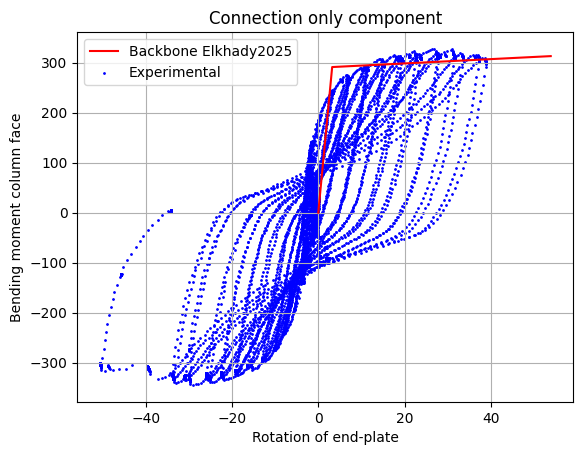

0.733
1.0750618187250514
0.05070037237059641
Ke = 90493.4 kNm/rad
My = 144.45 kNm
Mye = 291.39 kNm
Mc = 313.27 kNm
theta_y = 0.003220 rad = 3.220 mrad
theta_c = 0.053920 rad = 53.920 mrad
theta_p = 0.050700 rad


IMK with Pinched Response - Code by AE_KI (Sep23)


In [7]:
#Connection Elkhady 2025
#new class Connection
#the equations can be found in the paper some vars thet are needed for flush are commented 
#so upon addition remove the comments and add the if tree 
#
#current calcs are for stiff,sym EEPC 
#as per the publication units mm,Mpa, res KN,KNm,Knm/rad
#important part is input for calcs and fy etc are not values to be called blindly into the script unless its all in mm etc
fy_endplate=385.4#paper val from 10mm placeholder
fu_endplate=1.4*fy_endplate#paper val from 10mm placeholder
fy_col=399.1#from call notes 
fu_col=1.29*fy_col#from call notes 
fy_beam=403.9
fu_beam=1.24*fy_beam
fu_bolt=1000
class Connection:
    def __init__(self):
        self.tep=20#mm Thickness of endplate 
        self.g=120#self.tep+SecColmn.tf#bolt gauge length
        self.pt=60 #distance between the over/under flange bolt rows 
        self.db=27#bolt diameter
        #self.dt= #distance between the over flange bolt row and flange center 
        self.Ke=5.9*(self.pt**-1.21)*(self.g**-0.453)*(self.tep**1.14)*(SecColmn.tf**4.38)*(SecColmn.tw**-4.15)*(self.db**0.56)*(SecbeamX.h**2.15)*(SecColmn.h**-0.55)
        self.My=(3.78*10**-7)*(self.pt**-0.37)*(self.g**0.420)*(self.tep**0.8)*(SecColmn.tf**0.144)*(self.db**1.12)*(SecbeamX.h**1.47)*fy_endplate**0.91*fy_col**-0.11
        self.Mye=(6.3*10**-5)*(self.pt**-0.65)*(self.g**0.09)*(self.tep**0.59)*(SecColmn.tf**0.28)*(self.db**1.29)*(SecbeamX.h**1.35)*fy_endplate**0.61*fy_col**-0.04
        self.theta_y=self.Mye/self.Ke
        if 0.44*self.Mye<=self.My and self.My<=0.84*self.Mye:
            print('My check fulfilled')
        else:
            print('Parameters out of model')
        self.Mc=self.Mye*(0.84)*(self.pt**0.155)*(self.tep**-0.15)*(self.db**0.18)*(SecbeamX.h**-0.08)*(fu_endplate**0.18)*fy_endplate**-0.24*fu_col**0.19*fy_col**-0.31*fu_beam**0.14
        self.theta_c=(9.6*10**-5)*(self.pt**0.840)*(self.g**-1.1)*(self.tep**-0.3)*(SecColmn.tf**-1.34)*(self.db**3.9)*(SecbeamX.h**-0.91)*fy_endplate**-0.17*fy_col**-0.71*fu_bolt**1.5
        if self.theta_c>=1.5*self.Mye/self.Ke:
            print('Thetac check ok ')
        else :
         self.theta_c=1.5*self.Mye/self.Ke
#residuals not now especially since its formula is for loss of both series of bolts 

ExP = Connection()

thetas = np.array([0, ExP.theta_y, ExP.theta_c])
Ms      = np.array([0, ExP.Mye,ExP.Mc])
thetasmrad=thetas*1000
plt.plot(thetasmrad, Ms,color='red',label='Backbone Elkhady2025')
print('Ke0:',ExP.Ke)
print('My',ExP.My)
print('Mye',ExP.Mye)
print('Mc',ExP.Mc)
print('theta_y',ExP.theta_y)
print('theta_c',ExP.theta_c)
#print(SecColmn.h)#
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['E2'].value
y_label=ws['F2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=5,
    max_col=6,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue

plt.scatter(x, y,s=1,color='blue',label='Experimental')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.legend()
plt.title('Connection only component')
plt.grid()
plt.show()
ExP.lamda=0.8
ExP.c_expdet=2.0
D=1.0
Kappaf=0.8+0.023*ExP.pt/ExP.tep-0.34*ExP.g/SecColmn.b
#Kappaf=0.8
print(Kappaf)
Kappad=0.75
Mc_My=ExP.Mc/ExP.Mye
print(Mc_My)
print(ExP.theta_c-ExP.theta_y)
print(f"Ke = {ExP.Ke:.1f} kNm/rad")
print(f"My = {ExP.My:.2f} kNm")
print(f"Mye = {ExP.Mye:.2f} kNm")
print(f"Mc = {ExP.Mc:.2f} kNm")
print(f"theta_y = {ExP.theta_y:.6f} rad = {ExP.theta_y*1000:.3f} mrad")
print(f"theta_c = {ExP.theta_c:.6f} rad = {ExP.theta_c*1000:.3f} mrad")
print(f"theta_p = {ExP.theta_c - ExP.theta_y:.6f} rad")
#uniaxialMaterial     IMKPinching $Mat_Tag $Ke $dp_pos $dpc_pos $du_pos $Fy_pos $FmaxFy_pos $FresFy_pos 
#                                              $dp_neg $dpc_neg $du_neg $Fy_neg $FmaxFy_neg $FresFy_neg 
#                                              $Lamda_S $Lamda_C $Lamda_A $Lamda_K 
#                                              $c_S $c_C $c_A $c_K 
#                                              $D_pos $D_neg 
#                                              $kappaF $kappaD
#ops.uniaxialMaterial('IMKPinching',90,ExP.Ke,ExP.theta_c,(ExP.theta_c)*1.1,0.2,ExP.Mye,Mc_My,0.1,
#                                             ExP.theta_c,(ExP.theta_c)*1.1,0.2,ExP.Mye,Mc_My,0.1, 
#                                             ExP.lamda,ExP.lamda,ExP.lamda, ExP.lamda,
#                                             ExP.c_expdet,ExP.c_expdet,ExP.c_expdet,ExP.c_expdet,
#                                             1.0,1.0,
#                                             Kappaf,Kappad)
########################### MANUAL INPUT FROM EXPERIMENTS #############################
ops.uniaxialMaterial('IMKPinching',90,ExP.Ke,ExP.theta_c,(ExP.theta_c)+0.005,2*ExP.theta_c,ExP.Mye,1.227,0.65*ExP.Mc/ExP.Mye,
                                             ExP.theta_c,(ExP.theta_c)+0.005,2*ExP.theta_c,ExP.Mye,1.317,0.65*ExP.Mc/ExP.Mye, 
                                             0.716,0.716,0.716, 1.1432,
                                             ExP.c_expdet,ExP.c_expdet,ExP.c_expdet,ExP.c_expdet,
                                             1.0,1.0,
                                             0.62,0.63)


# 6 IMK Plastic Hinges for Beams and Columns 
as per Lignos 2013 Elkady and Hartloper 2019 via regression models  
see literature for caluculations based on section properites and material properties 

In [9]:
def Spring_IMK(SpringID,Mat_tag, Node_i, Node_j,SECTION,
               E, Fy,axis,
               L,Lb,PgPye,CompositeFLAG, ConnectionType,dof):
#  SpringID  			Spring ID
#  iNode	    		First node
#  jNode	    		Second node
#  E         			Young's modulus
#  Fy        			Yield stress
#  Ix        			Moment of inertia of section
#  d         			Section depth
#  tw        			Web thickness
#  bf        			Flange width
#  tf        			Flange thickness
#  htw        			Web slenderness ratio
#  bftf        			Flange slenderness ratio
#  L         			Member Length
#  Ls         			Shear Span
#  Lb        			Unbraced length
#  My        			Effective Yield Moment
#  PgPye        		Axial load ratio due to gravity
#  CompositeFLAG		FLAG for Composite Action Consideration: 0 --> Ignore   Composite Effect   
# 															 	 1 --> Consider Composite Effect
#  ConnectionType		Type of Connection: 0 --> Reduced     Beam Section  
# 											1 --> Non-Reduced Beam Section    
# 											2 --> Column Section   
#futher development a,Mmax=a*My Mr see lignos hartloper 2019 updates to ASCE 41 
# dimansions mm Mpa 
    print('Python version of IMK with Section databases updated for new Bilin by GR ')
    L=L*1000
    Lb=Lb*1000
    n =10.0
    # Unit factor for mm Mpa 
    c1 = 1.0
    c2 = 1.0
    c3 = 25.4
    c4 = 1000.0
    if axis=='y-y':
        Ix=SECTION.Iy
        ix=SECTION.iy
        My=SECTION.Mpl_Rd_y*(Fy/235)*1e6
    elif axis=='z-z':
        Ix=SECTION.Iz
        ix=SECTION.iz
        My=SECTION.Mel_Rd_z*(Fy/235)*1e6
    htw=SECTION.h/SECTION.tw
    #Lb=SECTION.Lp
    Ls=0.5*Lb
    ry=ix
    d=SECTION.h-2*SECTION.tf
    K = (n + 1.0)*6.0*E*Ix / L
    bftf=SECTION.b/SECTION.tf
    # ----------------------------------------------------------------------
    # CONNECTION TYPE 0: RBS
    # ----------------------------------------------------------------------
    if ConnectionType == 0:

        theta_p  = 0.19  * (htw ** -0.314) * (bftf ** -0.100) * ((Lb/ry) ** -0.185) * ((Ls/d) ** 0.113) \
                   * ((c1 * d/533) ** -0.760) * ((c2 * Fy*c4/355) ** -0.070)
        theta_pc = 9.52  * (htw ** -0.513) * (bftf ** -0.863) * ((Lb/ry) ** -0.108) \
                   * ((c2 * Fy*c4/355) ** -0.360)
        Lmda     = 585.0 * (htw ** -1.140) * (bftf ** -0.632) * ((Lb/ry) ** -0.205) \
                   * ((c2 * Fy*c4/355) ** -0.391)

        if CompositeFLAG == 0:
            MyPMy = 1.0; MyNMy = 1.0; McMyP = 1.1; McMyN = 1.1

            theta_y = My/(6*E*Ix/L)
            theta_p  = theta_p  - (McMyP-1.0)*My/(6*E*Ix/L)
            theta_pc = theta_pc + theta_y + (McMyP-1.0)*My/(6*E*Ix/L)

            theta_p_p  =theta_p
            theta_p_n  =theta_p
            theta_pc_p =theta_pc
            theta_pc_n =theta_pc
            theta_u    = 0.2
            My_P=MyPMy*My
            My_N=MyNMy*My
            D_P = 1.0; D_N = 1.0
            Res_P = 0.4; Res_N = 0.4

        else:
            MyPMy = 1.35; MyNMy = 1.25; McMyP = 1.30; McMyN = 1.05

            theta_y = My/(6*E*Ix/L)
            theta_p_p  =theta_p  - (McMyP-1.0)*My/(6*E*Ix/L)
            theta_p_n  =theta_p  - (McMyN-1.0)*My/(6*E*Ix/L)
            theta_pc_p =theta_pc + theta_y + (McMyP-1.0)*My/(6*E*Ix/L)
            theta_pc_n =theta_pc + theta_y + (McMyN-1.0)*My/(6*E*Ix/L)

            theta_p_P  = 1.80*theta_p_p
            theta_p_N  = 0.95*theta_p_n
            theta_pc_P = 1.35*theta_pc_p
            theta_pc_N = 0.95*theta_pc_n
            theta_u    = 0.2
            My_P=MyPMy*My
            My_N=MyNMy*My
            D_P = 1.15; D_N = 1.0
            Res_P = 0.3; Res_N = 0.2
        MrMy=0.1
    # ---------------------------------------------------------------------- # CONNECTION TYPE 1: Other-than-RBS (same logic structure)
    # ----------------------------------------------------------------------
    elif ConnectionType == 1:
        My=My*1.06
        if d > (c3*21.0):
            theta_p  = 0.318 * (htw ** -0.550) * (bftf ** -0.345) * ((Lb/ry) ** -0.023) \
                       * ((Ls/d) ** 0.090) * ((c1 * d/533) ** -0.330) \
                       * ((c2 * Fy*c4/355) ** -0.130)
            theta_pc = 7.50  * (htw ** -0.610) * (bftf ** -0.710) * ((Lb/ry) ** -0.110) \
                       * ((c1 * d/533) ** -0.161) * ((c2 * Fy*c4/355) ** -0.320)
            Lmda     = 536.0 * (htw ** -1.260) * (bftf ** -0.525) * ((Lb/ry) ** -0.130) \
                       * ((c2 * Fy*c4/355) ** -0.291)
        else:
            theta_p  = 0.0865 * (htw ** -0.360) * (bftf ** -0.140) * ((Ls/d) ** 0.340) \
                       * ((c1 * d/533) ** -0.721) * ((c2 * Fy*c4/355) ** -0.230)
            theta_pc = 5.63   * (htw ** -0.565) * (bftf ** -0.800) \
                       * ((c1 * d/533) ** -0.280) * ((c2 * Fy*c4/355) ** -0.430)
            Lmda     = 495.0  * (htw ** -1.340) * (bftf ** -0.595) \
                       * ((c2 * Fy*c4/355) ** -0.360)
        print('thp pre adj',theta_p)
        if CompositeFLAG == 0:
            MyPMy=1.0; MyNMy=1.0; McMyP=1.1; McMyN=1.1
            theta_y = My/(6*E*Ix/L)
            theta_p  = theta_p  # - (McMyP-1.0)*SECTION.My/(6*E*SECTION.Ix/L)
            theta_pc = theta_pc # + SECTION.theta_y + (McMyP-1.0)*SECTION.My/(6*E*SECTION.Ix/L)

            theta_p_P=theta_p; theta_p_N=theta_p
            theta_pc_P=theta_pc; theta_pc_N=theta_pc
            theta_u=0.2
            My_P=MyPMy*My
            My_N=MyNMy*My
            D_P=1.0; D_N=1.0
            Res_P=0.4; Res_N=0.4

        else:
            MyPMy=1.35; MyNMy=1.25; McMyP=1.30; McMyN=1.05
            theta_y = My/(6*E*Ix/L)
            theta_p_p  = theta_p  - (McMyP-1.0)*My/(6*E*Ix/L)
            theta_p_n  = theta_p  - (McMyN-1.0)*My/(6*E*Ix/L)
            theta_pc_p = theta_pc + theta_y + (McMyP-1.0)*My/(6*E*Ix/L)
            theta_pc_n = theta_pc + theta_y + (McMyN-1.0)*My/(6*E*Ix/L)
            theta_p_P=1.80*theta_p_p; theta_p_N=0.95*theta_p_n
            theta_pc_P=1.35*theta_pc_p; theta_pc_N=0.95*theta_pc_n
            theta_u=0.2
            My_P=MyPMy*My
            My_N=MyNMy*My
            D_P=1.15; D_N=1.0
            Res_P=0.3; Res_N=0.2
        MrMy=0.1
    # ----------------------------------------------------------------------
    # CONNECTION TYPE 2: COLUMN (2019 regressions)
    # ----------------------------------------------------------------------
    else:
        theta_p  = 294 * (htw ** -1.700) * ((Lb/ry) ** -0.700) * ((1-PgPye) ** 1.600)
        theta_pc = 90  * (htw ** -0.800) * ((Lb/ry) ** -0.800) * ((1-PgPye) ** 2.500)

        theta_p  = min(theta_p,0.2)
        theta_pc = min(theta_pc,0.3)

        if PgPye <= 0.35:
            Lmda = 25500 * (htw ** -2.140) * ((Lb/ry) ** -0.530) * ((1-PgPye) ** 4.920)
        else:
            Lmda = 26800 * (htw ** -2.300) * ((Lb/ry) ** -1.300) * ((1-PgPye) ** 1.190)

        if PgPye <= 0.2:
            My = (1.15/1.1)*My*(1-PgPye/2)
        else:
            My = (1.15/1.1)*My*(9/8)*(1-PgPye)
        #a in paper 
        McMy = 12.5 * (htw ** -0.200) * ((Lb/ry) ** -0.400) * ((1-PgPye) ** 0.400)
        McMy = max(1.0,min(McMy,1.3))

        MyPMy=1.0; MyNMy=1.0
        McMyP=McMy; McMyN=McMy

        print('thp pre adj',theta_p)
        theta_y = My/(6*E*Ix/L)
        theta_p  = theta_p  - (McMyP-1.0)*My/(6*E*Ix/L)
        theta_pc = theta_pc + theta_y + (McMyP-1.0)*My/(6*E*Ix/L)

        theta_p_P=theta_p; theta_p_N=theta_p
        theta_pc_P=theta_pc; theta_pc_N=theta_pc
        theta_u=0.15
        D_P=1.0; D_N=1.0
        Res_P = 0.5 - 0.4*PgPye
        Res_N = 0.5 - 0.4*PgPye
        MrMy=Res_P
    # ----------------------------------------------------------------------
    # MATERIAL & ELEMENT ASSEMBLY (same as TCL)
    # ----------------------------------------------------------------------
    My_P =  MyPMy * My
    My_N = -MyNMy *My

    as_mem_p =  (McMyP-1.)*My_P/(theta_p_P * 6.*E * Ix/L)
    as_mem_n = -(McMyN-1.)*My_N/(theta_p_N * 6.*E * Ix/L)

    SH_mod_P = as_mem_p/(1.0+n*(1.0-as_mem_p))
    SH_mod_N = as_mem_n/(1.0+n*(1.0-as_mem_n))

    K=K*1e-6
    My_P=My_P*1e-6
    My_N=My_N*1e-6
    L_S = Lmda; L_C=Lmda; L_A=Lmda; L_K=Lmda
    c_S=1.0; c_C=1.0; c_A=1.0; c_K=1.0
    #uniaxialMaterial IMKBilin $matTag $Ke $dp_pos $dpc_pos $du_pos $Fy_pos $FmaxFy_pos $FresFy_pos 
    #                                      $dp_neg $dpc_neg $du_neg $Fy_neg $FmaxFy_neg $FresFy_neg 
    #                                      $Lamda_S $Lamda_C $Lamda_K $c_S $c_C $c_K $D_pos $D_neg
    
    ops.uniaxialMaterial('IMKBilin',Mat_tag,K,My_P/K+theta_p_P,My_P/K+theta_p_P+theta_pc_P,My_P/K+theta_p_P+theta_pc_P+theta_u,My_P,McMyP,MrMy,
                                               My_N/K+theta_p_P,My_N/K+theta_p_N+theta_pc_N,My_P/K+theta_p_N+theta_pc_N+theta_u,My_N,McMyN,MrMy,
                                                L_S, L_C,L_K,c_S,c_C,c_K,D_P, D_N)              
    print('IMKBilin updated Version')
    #ops.uniaxialMaterial('Bilin', SpringID, K, SH_mod_P, SH_mod_N,
    #                     SECTION.My_P, SECTION.My_N, L_S, L_C, L_A, L_K,
    #                     c_S, c_C, c_A, c_K,
    #                     SECTION.theta_p_P, SECTION.theta_p_N, SECTION.theta_pc_P, SECTION.theta_pc_N,
    #                     Res_P, Res_N, SECTION.theta_u, SECTION.theta_u, )
    print('My',My_P,'K',K,'thp',theta_p_P,'thpc',theta_pc_P)
    ops.element('zeroLength', SpringID, Node_i, Node_j,
                '-mat', Mat_tag, '-dir',dof)
    plt.plot([0,My_P/K,My_P/K+theta_p_P,My_P/K+theta_p+theta_pc_P,My_P/K+theta_pc+theta_p+0.2],[0,My_P,My_P*McMyP,My_P*MrMy,My_P*MrMy])

# 7 Contructing panel 
automated based on centerline node on grid object no node is being constructed in the center line as it triggers numerical collapse     
see notation bellow for nodes tags etc  
spring is added later in the upper right conrer 
attention is needed in the Stiffness and Area of the rigid links in order not to trigger numerical instabilities due to non  convergance 


In [11]:
Unitsmulti=0.001
A_panel=100#stiff
I_panel=100#stiff
E_panel=210000.0#
SECBEAMX=SecbeamX
SECCOLMN=SecColmn
TransfpanelTag=Pdelta1
def Construct_Panel(NodeDummy_Gridline,SECBEAMX,SECCOLMN,I_panel,A_panel,TransfpanelTag,Unitsmulti):
        #node notation $$40dummynodegridline0i $around the panel node % dummy node at the center line
        #Nodedummy dummy grid tag from Grid.ops object or manually assigned node dirrectly through user 
        #SECS sections object from dictionary or otherwise attention 
        #Unitsmulti is needed as Section vals for geometry are all in mm if other dictionary is used adjust the units 
        #Ipanel :stiff or otherwise through modeling assumptions for Rigid links/Elastic members for square
        #Apanel :see above   
    #                            7|8------3-----9!10
    #                             !              !
    #                             !              !
    #                             2  dummy node  4
    #                             !   gridline   !
    #                             !              !
    #                            6|5------1----12!11
    #    
    NodeDummy_Gridline_coords=Gridops_ops(int(NodeDummy_Gridline),Gridops,'coords')
    SECBEAMX.d=SECBEAMX.h-2*SECBEAMX.tf
    SECCOLMN.d=SECCOLMN.h-2*SECCOLMN.tf
    Node_tag_panel_01=4*10**5+NodeDummy_Gridline*100+1
    Node_tag_panel_02=4*10**5+NodeDummy_Gridline*100+2
    Node_tag_panel_03=4*10**5+NodeDummy_Gridline*100+3
    Node_tag_panel_04=4*10**5+NodeDummy_Gridline*100+4
    Node_tag_panel_05=4*10**5+NodeDummy_Gridline*100+5
    Node_tag_panel_06=4*10**5+NodeDummy_Gridline*100+6
    Node_tag_panel_07=4*10**5+NodeDummy_Gridline*100+7
    Node_tag_panel_08=4*10**5+NodeDummy_Gridline*100+8
    Node_tag_panel_09=4*10**5+NodeDummy_Gridline*100+9
    Node_tag_panel_10=4*10**5+NodeDummy_Gridline*100+10
    Node_tag_panel_11=4*10**5+NodeDummy_Gridline*100+11
    Node_tag_panel_12=4*10**5+NodeDummy_Gridline*100+12
    #panel zone rigid frame
    panel_ele_01=40*10**5+NodeDummy_Gridline*100+1
    panel_ele_02=40*10**5+NodeDummy_Gridline*100+2
    panel_ele_03=40*10**5+NodeDummy_Gridline*100+3
    panel_ele_04=40*10**5+NodeDummy_Gridline*100+4
    panel_ele_05=40*10**5+NodeDummy_Gridline*100+5
    panel_ele_06=40*10**5+NodeDummy_Gridline*100+6
    panel_ele_07=40*10**5+NodeDummy_Gridline*100+7
    panel_ele_08=40*10**5+NodeDummy_Gridline*100+8
    #Constructing panel coors
    dummy_panel=NodeDummy_Gridline_coords+np.array([0,-0.5*SECBEAMX.d*Unitsmulti])
    ops.node(Node_tag_panel_01,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([-0.5*SECCOLMN.d*Unitsmulti,0])
    ops.node(Node_tag_panel_02,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([0,0.5*SECBEAMX.d*Unitsmulti])
    ops.node(Node_tag_panel_03,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([0.5*SECCOLMN.d*Unitsmulti,0])
    ops.node(Node_tag_panel_04,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([-0.5*SECCOLMN.d*Unitsmulti,-0.5*SECBEAMX.d*Unitsmulti])
    ops.node(Node_tag_panel_05,*dummy_panel)
    ops.node(Node_tag_panel_06,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([-0.5*SECCOLMN.d*Unitsmulti,0.5*SECBEAMX.d*Unitsmulti])
    ops.node(Node_tag_panel_07,*dummy_panel)
    ops.node(Node_tag_panel_08,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([0.5*SECCOLMN.d*Unitsmulti,0.5*SECBEAMX.d*Unitsmulti])
    ops.node(Node_tag_panel_09,*dummy_panel)
    ops.node(Node_tag_panel_10,*dummy_panel)
    dummy_panel=NodeDummy_Gridline_coords+np.array([0.5*SECCOLMN.d*Unitsmulti,-0.5*SECBEAMX.d*Unitsmulti])
    ops.node(Node_tag_panel_11,*dummy_panel)
    ops.node(Node_tag_panel_12,*dummy_panel)
    #Panel elements without the Rot Spring
    #ops.element('elasticBeamColumn', eleTag, *eleNodes, Area, E_mod, Iz, transfTag, <'-mass', mass>, <'-cMass'>, <'-release', releaseCode>)
    ops.element('elasticBeamColumn',panel_ele_01,Node_tag_panel_01,Node_tag_panel_05,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_02,Node_tag_panel_06,Node_tag_panel_02,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_03,Node_tag_panel_02,Node_tag_panel_07,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_04,Node_tag_panel_08,Node_tag_panel_03,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_05,Node_tag_panel_03,Node_tag_panel_09,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_06,Node_tag_panel_10,Node_tag_panel_04,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_07,Node_tag_panel_04,Node_tag_panel_11,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    ops.element('elasticBeamColumn',panel_ele_08,Node_tag_panel_12,Node_tag_panel_01,A_panel,E_panel*1e3,I_panel,TransfpanelTag)
    #equaldofs retrain nodes at corners one spring controlling the whole 3 bending rotation (in panel Shear movement) 
    #ops.equalDOF(MasterNodeTag, SlaveNodeTag, *dofs)
    ops.equalDOF(Node_tag_panel_05,Node_tag_panel_06,1,2)
    ops.equalDOF(Node_tag_panel_07,Node_tag_panel_08,1,2)
    ops.equalDOF(Node_tag_panel_09,Node_tag_panel_10,1,2)#location of spring
    ops.equalDOF(Node_tag_panel_11,Node_tag_panel_12,1,2)
    #ops.equalDOF(Node_tag_panel_09,NodeDummy_Gridline,1,2,3)


# 8 Equal dof
based on the tag of each node based on its usage    
the hiearchy is Joint( panel zone )- connection - rigid offest of plastic hinge - Plastic hinge of beam - Beam element  
same for column but skipping the connection and the rigid offset    
for distibuted plasticity: joint-connection-element     

In [12]:
def nodeEQ_DOF_notation(tag,Eqdof_specific_tag,orientation,dofs):
        #Code to produce equal dof based otn the notation drawings and the specific tags
        # only the panelzone is stand alone are its needs several all at once
        #for element tags same goes but with variations
        #corrected to assume the offset of the panel offset coos into account
        #for 3d the X0,Y0,Z0 is needed 
        if Eqdof_specific_tag==7:
                print('Connection at Base Nodes :')
                Dummy_master=tag
                print('-Master Node',Dummy_master)
        elif Eqdof_specific_tag==6:
                print('Beam Concentrated Plasticity Nodes Start:')
                Dummy_master=9*10**5+tag*100+orientation
                print('-Master Node through rigid ele with Lp offset',Dummy_master)
                Dummy_slave=Eqdof_specific_tag*10**5+tag*100+orientation
                print('-Offset Lp Node',Dummy_slave)
                X0,Y0=ops.nodeCoord(int(Dummy_master))
                if orientation==2:
                        X0=X0-SecbeamX.Lp*Unitsmulti#Lp is in mmif the database is changed this needs to be changed-checked too
                elif orientation==4:
                        X0=X0+SecbeamX.Lp*Unitsmulti#Lp is in mmif the database is changed this needs to be changed-checked too
                else:
                     print('Orientation wrong check notation')   
                ops.node(Dummy_slave,X0,Y0)  #for panelzone the nodes are already in place through the Conctruct panel 
                print('Beam Concentrated Plasticity Nodes End:')
                Dummy_master=Eqdof_specific_tag*10**5+tag*100+orientation
                print('-Master Node Start Hinge',Dummy_master)
                #Dummy_slave=Eqdof_specific_tag*10**5+tag*100+orientation
                #print('-Slave Node',Dummy_slave)
                #X0,Y0=ops.nodeCoord(int(Dummy_master))
        elif Eqdof_specific_tag==9:
                print('Conection Nodes:')
                Dummy_master=4*10**5+tag*100+orientation
                print('-Master Node',Dummy_master)
        elif Eqdof_specific_tag==5:
                print('Column Concentrated Plasticity Nodes:')
                Dummy_master=4*10**5+tag*100+orientation
                print('-Master Node',Dummy_master)
                #ops.node(Dummy_master,X0,Y0)
        if Eqdof_specific_tag==6:
                Dummy_slave=6*10**5+tag*100+orientation+orientation*10
        else:
                Dummy_slave=Eqdof_specific_tag*10**5+tag*100+orientation
        print('-Slave Node',Dummy_slave)
        X0,Y0=ops.nodeCoord(int(Dummy_master))
        ops.node(Dummy_slave,X0,Y0)               #for panelzone the nodes are already in place through the Conctruct panel 
        ops.equalDOF(int(Dummy_master),int(Dummy_slave),*dofs)
        ops.getNodeTags()#control

# 9 Panel Zones Spiring Model
Control panel for comparisson of spring models based on a joint type preset you can add more options as well    
Contruction  of PZ springs function  for each model type each curve is first for shear and then using the lever arm to moment

J= 407944002.6666667
G= 80769.23076923077
1700125000.0


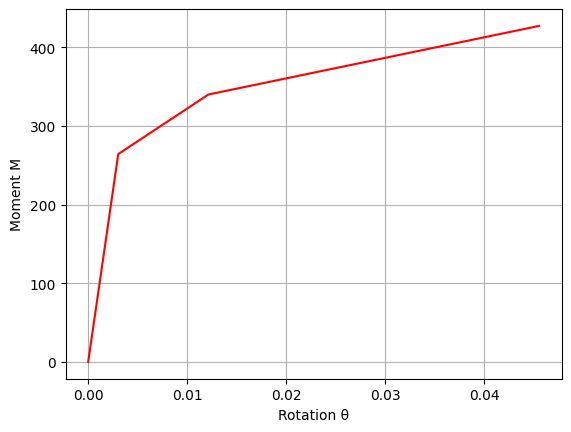

gamma_y= 0.003148228571428572
gamma_pz= 0.010698219203652336
Vcw= 1329096.1320000002
Vcf= 234946.38800970875
Vy= 1398235.2024757285
Vpz= 1659664.5161728219


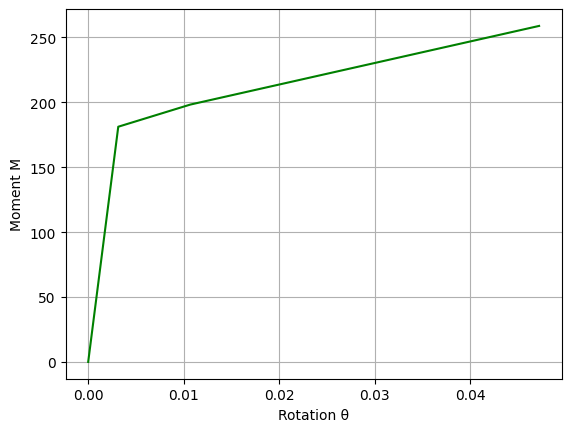

0.04962719554962916


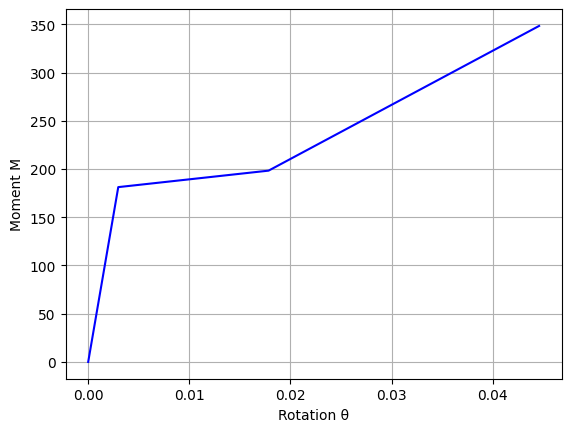

In [13]:
#Panel Zone Control Panel 
#GJ needed for fiber sections and forceebamcol eles to induce torsion 
SecColmn.J=2*((SecColmn.tf*SecColmn.b**3)/3)+(SecColmn.tw*(SecColmn.h-2*SecColmn.tf)**3)/3
print('J=',SecColmn.J)
#for elastic range poissonratio 0.3 E 210000
#can be grouped with mat once built 
E=210000
poissonratio=0.3
#G needed also for oanel zone calcs
SecColmn.G=E/(2*(1+poissonratio))
print('G=',SecColmn.G)
prop=19430000.0*E/2400
print(prop)
G=SecColmn.G
tdplate=10#mm placeholder value from shaketable ,same for the SP_S tests  
ndplates=1# 1 for corner in SP_S, 2 for for middle SP_S, 2 for sheke table  
SH_Panel=0.03
fy_col_w=423.8
#def Spring_Panel_Kraw(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardeningratio,G,ndplates,tdplate):
#Panel needs to be constructed before the spring is called 
#uniaxialMaterial('ModIMKPeakOriented', matTag, K0, as_Plus, as_Neg, My_Plus, My_Neg, Lamda_S, Lamda_C, Lamda_A, Lamda_K, c_S, c_C, c_A, c_K, theta_p_Plus, theta_p_Neg, theta_pc_Plus, theta_pc_Neg, Res_Pos, Res_Neg, theta_u_Plus, theta_u_Neg, D_Plus, D_Neg)
hslab=0#Slabthicknes above rib
trib=0#Steel deck rib depth 
tp=SECCOLMN.tw+ndplates*tdplate#total thickness of panel zone plus coverplates on web 
SECBEAMX.dpos=SECBEAMX.d+hslab+trib-0.5*hslab#in SPC_S2/4 doesnot really matter as the frame is completely bare 
SECBEAMX.dneg=SECBEAMX.d                     #in SPC_S2/4 doesnot really matter as the frame is completely bare 
Vy=0.55*fy_col_w*SECCOLMN.d*tp
Ke=0.95*G*tp*SECCOLMN.d
gamma1_y=Vy/Ke
gamma2_y=4*gamma1_y
gamma3_y=15*gamma1_y
KpP=0.95*G*SECCOLMN.b*(SECCOLMN.tf**2)/SECBEAMX.dpos
M1yP=gamma1_y*(Ke*SECBEAMX.dpos)*10**-6
M2yP=M1yP+(KpP*SECBEAMX.dpos)*(gamma2_y-gamma1_y)*10**-6
M3yP=M2yP+(SH_Panel*Ke*SECBEAMX.dpos)*(gamma3_y-gamma2_y)*10**-6
KpN=0.95*G*SECCOLMN.b*(SECCOLMN.tf**2)/SECBEAMX.dneg
M1yN=gamma1_y*(Ke*SECBEAMX.dneg)*10**-6
M2yN=M1yN+(KpN*SECBEAMX.dneg)*(gamma2_y-gamma1_y)*10**-6
M3yN=M2yN+(SH_Panel*Ke*SECBEAMX.dneg)*(gamma3_y-gamma2_y)*10**-6
theta_up=0.3
theta_un=-0.3
Ke=Ke*1e-3
gamma1_kr=gamma1_y
gamma2_kr=gamma2_y
gamma3_kr=gamma3_y
M1yP_kr=M1yP
M2yP_kr=M2yP
M3yP_kr=M3yP
plt.plot([0,gamma1_kr,gamma2_kr,gamma3_kr],[0,M1yP_kr,M2yP_kr,M3yP_kr],color='red',label='Krawinkler')
plt.xlabel("Rotation θ")
plt.ylabel("Moment M")
plt.grid(True)
plt.show()
#def Spring_Panel_Kim(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardenongratio,G,ndplates,tdplate):
hslab=0
trib=0
tp=SECCOLMN.tw+ndplates*tdplate
Vcw=0.6*fy_col_w*0.95*tp*SECCOLMN.d
Kcw=0.95*SECCOLMN.d*tp*G
gamma_y=Vcw/Kcw
a=SECBEAMX.d/SECCOLMN.tf
gamma_pz=(0.475*fy_col_w/E)*(a+3.45/a)
Kcf=(1.11*E*SECCOLMN.b*SECCOLMN.tf)/(a**2+3.45)

Vcf=gamma_pz*2*Kcf
print('gamma_y=',gamma_y)
print('gamma_pz=',gamma_pz)
print('Vcw=',Vcw)
print('Vcf=',Vcf)
Vy=Vcw+2*Kcf*gamma_y
Vpz=0.03*Kcw*(gamma_pz-gamma_y)+Vy+2*Kcf*(gamma_pz-gamma_y)
print('Vy=',Vy)
print('Vpz=',Vpz)
M1yP=Kcw*gamma_y*SECCOLMN.d*0.5*10**-6+2*Kcf*gamma_y*SECBEAMX.d*0.5*10**-6
M2yP=M1yP+(0.03*Kcw*(gamma_pz-gamma_y)*SECCOLMN.d*0.5*10**-6+2*Kcf*(gamma_pz-gamma_y)*SECBEAMX.d*0.5)*10**-6
gamma_u=15*gamma_y
M3yP=M2yP+(0.03*Kcw*(gamma_u-gamma_pz)*SECCOLMN.d*0.5)*10**-6
theta_up=0.3
theta_un=-0.3
gamma1_y=gamma_y
gamma2_y=gamma_pz
gamma3_y=gamma_u
M1yN=M1yP
M2yN=M2yP
M3yN=M3yP
#plt.plot([0,gamma1_y,gamma2_y],[0,M1yP,M2yP])
gamma1_kim=gamma1_y
gamma2_kim=gamma2_y
gamma3_kim=gamma3_y
M1yP_kim=M1yP
M2yP_kim=M2yP
M3yP_kim=M3yP
plt.plot([0,gamma1_kim,gamma2_kim,gamma3_kim],[0,M1yP_kim,M2yP_kim,M3yP_kim],color='green',label='Kim')
plt.xlabel("Rotation θ")
plt.ylabel("Moment M")
plt.grid(True)
plt.show()
#def Spring_Panel_LgSk(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardeningratio,G,ndplates,tdplate):
# Geometry
tpz = SECCOLMN.tw + ndplates * tdplate
d_Col = SECCOLMN.h-2*SECCOLMN.tf
d_Beam = SECBEAMX.h-2*SECBEAMX.tf
tf_Col = SECCOLMN.tf
bf_Col = SECCOLMN.b
tw_Col = SECCOLMN.tw
Ix_Col = SECCOLMN.Iy
# Beam effective depth (bare steel, no composite action)
d_BeamP = d_Beam
d_BeamN = d_Beam
# Stiffness calculation (shear + bending in series)
Ks = tpz * (d_Col - tf_Col) * G  # Shear stiffness
# Bending stiffness of panel zone
I_pz = Ix_Col +ndplates*tdplate * ((d_Col - 2*tf_Col)**3) / 12  # Add doubler plate inertia
Kb = 12 * E * I_pz / (d_Beam**3) * d_Beam
# Combined stiffness (series)
Ke = (Ks * Kb) / (Ks + Kb)
# Flange contribution stiffness
Ksf = 2 * bf_Col * tf_Col * G
Kbf = 2 * 12 * E * bf_Col * (tf_Col**3) / 12 / (d_Beam**3) * d_Beam
Kef = (Ksf * Kbf) / (Ksf + Kbf)
print(Kef/Ke)
ratio_mode=Kef/Ke
# Effectiveness factors
if ratio_mode>=0.07:
    print('stocky bending mode negl')
    ay=1.0
elif ratio_mode<=0.02:
    print('slender')
    ay=0.9
else:
    ay = (0.58 * Kef/Ke + 0.88) / (1 - Kef/Ke)
aw_eff_4gamma = 1.10
aw_eff_6gamma = 1.2
af_eff_4gamma = 0.93 * Kef/Ke + 0.015
af_eff_6gamma = 1.05 * Kef/Ke + 0.020
# Strength calculations
Vy = 0.577 * fy_col_w * ay * (d_Col - tf_Col) * tpz  # kN
Vp_4gamma = 0.577 * fy_col_w * (
    aw_eff_4gamma * (d_Col - tf_Col) * tpz + 
    af_eff_4gamma * (bf_Col - tw_Col) * 2 * tf_Col
)
Vp_6gamma = 0.577 * fy_col_w * (
    aw_eff_6gamma * (d_Col - tf_Col) * tpz +
    af_eff_6gamma * (bf_Col - tw_Col) * 2 * tf_Col
)
# Distortions
gamma_y = Vy / Ke
gamma1_y = gamma_y
gamma2_y = 6 * gamma_y
gamma3_y = 15 * gamma_y  # NOT 100*gamma_y!
# Moments (force × lever arm)
My_P = Vy * d_BeamP / 1000000  # N*mm → kNm
Mp_4gamma_P = Vp_4gamma * d_BeamP / 1000000
Mp_6gamma_P = Vp_6gamma * d_BeamP / 1000000
# Same for negative
My_N = Vy * d_BeamN / 1000000
Mp_4gamma_N = Vp_4gamma * d_BeamN / 1000000
Mp_6gamma_N = Vp_6gamma * d_BeamN / 1000000
# Slope from 4γ to 6γ
M1yP_LgSk = My_P
#M2yP_LgSk = Mp_4gamma_P
M2yP_LgSk = Mp_6gamma_P# + Slope_P * (gamma3_y - gamma2_y)
M3yP=M2yP_LgSk+(SH_Panel*Ke*1e-3*SECBEAMX.dpos)*(gamma3_y-gamma2_y)*10**-9
gamma1_LgSk=gamma1_y
gamma2_LgSk=gamma2_y
gamma3_LgSk=gamma3_y
M1yP_LgSk=M1yP
M2yP_LgSk=M2yP
M3yP_LgSk=M3yP
plt.plot([0,gamma1_LgSk,gamma2_LgSk,gamma3_LgSk],[0,M1yP_LgSk,M2yP_LgSk,M3yP_LgSk],color='blue',label='Skiadakopoulos')
plt.xlabel("Rotation θ")
plt.ylabel("Moment M")
plt.grid(True)
plt.show()


In [14]:
#GJ needed for fiber sections and forceebamcol eles to induce torsion 
SecColmn.J=2*((SecColmn.tf*SecColmn.b**3)/3)+(SecColmn.tw*(SecColmn.h-2*SecColmn.tf)**3)/3
print('J=',SecColmn.J)
#for elastic range poissonratio 0.3 E 210000
#can be grouped with mat once built 
E=210000
poissonratio=0.3
#G needed also for oanel zone calcs
SecColmn.G=E/(2*(1+poissonratio))
print('G=',SecColmn.G)
prop=19430000.0*E/2400
print(prop)
G=SecColmn.G
tdplate=10#mm placeholder value from shaketable ,same for the SP_S tests  
ndplates=1# 1 for corner in SP_S, 2 for for middle SP_S, 2 for sheke table  
SH_Panel=0.03
fy_col_w=423.8
def Spring_Panel_Kraw(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardeningratio,G,ndplates,tdplate):
    #Panel needs to be constructed before the spring is called 
    #uniaxialMaterial('ModIMKPeakOriented', matTag, K0, as_Plus, as_Neg, My_Plus, My_Neg, Lamda_S, Lamda_C, Lamda_A, Lamda_K, c_S, c_C, c_A, c_K, theta_p_Plus, theta_p_Neg, theta_pc_Plus, theta_pc_Neg, Res_Pos, Res_Neg, theta_u_Plus, theta_u_Neg, D_Plus, D_Neg)
    hslab=0#Slabthicknes above rib
    trib=0#Steel deck rib depth 
    tp=SECCOLMN.tw+ndplates*tdplate#total thickness of panel zone plus coverplates on web 
    SECBEAMX.dpos=SECBEAMX.d+hslab+trib-0.5*hslab#in SPC_S2/4 doesnot really matter as the frame is completely bare 
    SECBEAMX.dneg=SECBEAMX.d                     #in SPC_S2/4 doesnot really matter as the frame is completely bare 
    Vy=0.55*fy_col_w*SECCOLMN.d*tp
    Ke=0.95*G*tp*SECCOLMN.d
    gamma1_y=Vy/Ke
    gamma2_y=4*gamma1_y
    gamma3_y=15*gamma1_y
    KpP=0.95*G*SECCOLMN.b*(SECCOLMN.tf**2)/SECBEAMX.dpos
    M1yP=gamma1_y*(Ke*SECBEAMX.dpos)*10**-6
    M2yP=M1yP+(KpP*SECBEAMX.dpos)*(gamma2_y-gamma1_y)*10**-6
    M3yP=M2yP+(SH_Panel*Ke*SECBEAMX.dpos)*(gamma3_y-gamma2_y)*10**-6
    KpN=0.95*G*SECCOLMN.b*(SECCOLMN.tf**2)/SECBEAMX.dneg
    M1yN=gamma1_y*(Ke*SECBEAMX.dneg)*10**-6
    M2yN=M1yN+(KpN*SECBEAMX.dneg)*(gamma2_y-gamma1_y)*10**-6
    M3yN=M2yN+(SH_Panel*Ke*SECBEAMX.dneg)*(gamma3_y-gamma2_y)*10**-6
    theta_up=0.3
    theta_un=-0.3
    Ke=Ke*1e-3
    plt.plot([0,gamma1_y,gamma2_y,gamma3_y],[0,M1yP,M2yP,M3yP])
    plt.xlabel("Rotation θ")
    plt.ylabel("Moment M")
    plt.grid(True)
    plt.show()
    print('M1yp',M1yP,'M2yp',M2yP,'M3yP',M3yP)
    print('g1',gamma1_y,'g2',gamma2_y,'g3',gamma3_y)
    print('Ke=',Ke)
    print('KnP=',KpP)
    print('KnN=',KpN)
    paneldummytag=4*10**5+DUMMYNODE*100
    eletag=40*10**5+DUMMYNODE*100
    dummytag=eletag+40
    ops.uniaxialMaterial(
    "Hysteretic",dummytag,
    *[M1yP , gamma1_y],
    *[M2yP , gamma2_y],
    *[M3yP , gamma3_y],
    *[-M1yN,-gamma1_y],
    *[-M2yN,-gamma2_y],
    *[-M3yN,-gamma3_y],
    0.25, 0.75, 0.00, 0.00, 0.5
    )
    ops.uniaxialMaterial('MinMax',eletag,dummytag,'-min',theta_un,'-max',theta_up)
    ops.element('zeroLength',eletag,paneldummytag+9,paneldummytag+10,'-mat',eletag,'-dir',3)
    # Debug output
    print(f"Panel zone Hysteretic backbone points:")
    print(f"  M1yP = {M1yP:.1f} kNm at γ1 = {gamma1_y*1000:.2f} mrad")
    print(f"  M2yP = {M2yP:.1f} kNm at γ2 = {gamma2_y*1000:.2f} mrad")
    print(f"  M3yP = {M3yP:.1f} kNm at γ3 = {gamma3_y*1000:.2f} mrad")
    print(f"Panel zone {DUMMYNODE}:")
    print(f"  Hysteretic mat: {dummytag}")
    print(f"  Element: {eletag}")
    print(f"  Limits: {theta_un:.4f} to {theta_up:.4f} rad")
    print(f"  Limits: {theta_un*1000:.1f} to {theta_up*1000:.1f} mrad")
    print(f"dc (SECCOLMN.h) = {SECCOLMN.h}")
    print(f"d (SECCOLMN.d) = {SECCOLMN.d}")  
    print(f"dpos (SECBEAMX.dpos) = {SECBEAMX.dpos}")
    print(f"tp = {tp}")
    print(f"Vy = {Vy}")
    print(f"Ke (before 1e-3) = {Ke}")


J= 407944002.6666667
G= 80769.23076923077
1700125000.0


In [15]:
def Spring_Panel_Kim(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardenongratio,G,ndplates,tdplate):
    hslab=0
    trib=0
    tp=SECCOLMN.tw+ndplates*tdplate
    Vcw=0.6*fy_col_w*0.95*tp*SECCOLMN.d
    Kcw=0.95*SECCOLMN.d*tp*G
    gamma_y=Vcw/Kcw
    a=SECBEAMX.d/SECCOLMN.tf
    gamma_pz=(0.475*fy_col_w/E)*(a+3.45/a)
    Kcf=(1.11*E*SECCOLMN.b*SECCOLMN.tf)/(a**2+3.45)
    
    Vcf=gamma_pz*2*Kcf
    print('gamma_y=',gamma_y)
    print('gamma_pz=',gamma_pz)
    print('Vcw=',Vcw)
    print('Vcf=',Vcf)
    Vy=Vcw+2*Kcf*gamma_y
    Vpz=0.03*Kcw*(gamma_pz-gamma_y)+Vy+2*Kcf*(gamma_pz-gamma_y)
    print('Vy=',Vy)
    print('Vpz=',Vpz)
    M1yP=Kcw*gamma_y*SECCOLMN.d*0.5*10**-6+2*Kcf*gamma_y*SECBEAMX.d*0.5*10**-6
    M2yP=M1yP+(0.03*Kcw*(gamma_pz-gamma_y)*SECCOLMN.d*0.5*10**-6+2*Kcf*(gamma_pz-gamma_y)*SECBEAMX.d*0.5)*10**-6
    gamma_u=25*gamma_y
    M3yP=M2yP+(0.03*Kcw*(gamma_u-gamma_pz)*SECCOLMN.d*0.5)*10**-6
    theta_up=0.3
    theta_un=-0.3
    gamma1_y=gamma_y
    gamma2_y=gamma_pz
    gamma3_y=gamma_u
    M1yN=M1yP
    M2yN=M2yP
    M3yN=M3yP
    #plt.plot([0,gamma1_y,gamma2_y],[0,M1yP,M2yP])
    plt.plot([0,gamma1_y,gamma2_y,gamma3_y],[0,M1yP,M2yP,M3yP])
    plt.xlabel("Rotation θ")
    plt.ylabel("Moment M")
    plt.grid(True)
    plt.show()
    print('M1yp',M1yP,'M2yp',M2yP,'M3yP',M3yP)
    print('g1',gamma1_y,'g2',gamma2_y,'g3',gamma3_y)
    paneldummytag=4*10**5+DUMMYNODE*100
    eletag=40*10**5+DUMMYNODE*100
    dummytag=eletag+40
    ops.uniaxialMaterial(
    "Hysteretic",dummytag,
    *[M1yP , gamma1_y],
    *[M2yP , gamma2_y],
    *[M3yP , gamma3_y],
    *[-M1yN,-gamma1_y],
    *[-M2yN,-gamma2_y],
    *[-M3yN,-gamma3_y],
    0.0, 0.0, 0.08, 0.08, 0.0
    )
    ops.uniaxialMaterial('MinMax',eletag,dummytag,'-min',theta_un,'-max',theta_up)
    ops.element('zeroLength',eletag,paneldummytag+9,paneldummytag+10,'-mat',eletag,'-dir',3)

In [16]:
def Spring_Panel_Manual(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardeningratio,G,ndplates,tdplate):
    #Panel needs to be constructed before the spring is called 
    #uniaxialMaterial('ModIMKPeakOriented', matTag, K0, as_Plus, as_Neg, My_Plus, My_Neg, Lamda_S, Lamda_C, Lamda_A, Lamda_K, c_S, c_C, c_A, c_K, theta_p_Plus, theta_p_Neg, theta_pc_Plus, theta_pc_Neg, Res_Pos, Res_Neg, theta_u_Plus, theta_u_Neg, D_Plus, D_Neg)
    hslab=0#Slabthicknes above rib
    trib=0#Steel deck rib depth 
    tp=SECCOLMN.tw+ndplates*tdplate#total thickness of panel zone plus coverplates on web 
    SECBEAMX.dpos=SECBEAMX.d+hslab+trib-0.5*hslab#in SPC_S2/4 doesnot really matter as the frame is completely bare 
    SECBEAMX.dneg=SECBEAMX.d                     #in SPC_S2/4 doesnot really matter as the frame is completely bare 
    Vy=0.577*fy_col*(SECCOLMN.d-SECCOLMN.tf)*tp
    Ks=tp*(SECCOLMN.d-SECCOLMN.tf)*G
    Kb=12*E*SECCOLMN.Iy*SECBEAMX.d
    Ke=(Ks*Kb)/(Ks+Kb)
    gamma1_y=Vy/Ke
    gamma2_y=4*gamma1_y
    gamma3_y=25*gamma1_y
    KpP=0.95*G*SECCOLMN.b*(SECCOLMN.tf**2)/SecbeamX.dpos
    M1yP=gamma1_y*(Ke*SecbeamX.dpos)*10**-6
    M2yP=M1yP+(KpP*SecbeamX.dpos)*(gamma2_y-gamma1_y)*10**-6
    M3yP=M2yP+(SH_Panel*Ke*SecbeamX.dpos)*(gamma3_y-gamma2_y)*10**-6
    KpN=0.95*G*SECCOLMN.b*(SECCOLMN.tf**2)/SecbeamX.dneg
    M1yN=gamma1_y*(Ke*SecbeamX.dneg)*10**-6
    M2yN=M1yN+(KpN*SecbeamX.dneg)*(gamma2_y-gamma1_y)*10**-6
    M3yN=M2yN+(SH_Panel*Ke*SecbeamX.dneg)*(gamma3_y-gamma2_y)*10**-6
    theta_up=0.3
    theta_un=-0.3
    Ke=Ke*1e-3
    plt.plot([0,gamma1_y,gamma2_y,gamma3_y],[0,M1yP,M2yP,M3yP])
    plt.xlabel("Rotation θ")
    plt.ylabel("Moment M")
    plt.grid(True)
    plt.show()
    print('M1yp',M1yP,'M2yp',M2yP,'M3yP',M3yP)
    print('g1',gamma1_y,'g2',gamma2_y,'g3',gamma3_y)
    print('Ke=',Ke)
    print('KnP=',KpP)
    print('KnN=',KpN)
    paneldummytag=4*10**5+DUMMYNODE*100
    eletag=40*10**5+DUMMYNODE*100
    dummytag=eletag+40
    ops.uniaxialMaterial(
    "Hysteretic",dummytag,
    *[M1yP , gamma1_y],
    *[M2yP , gamma2_y],
    *[M3yP , gamma3_y],
    *[-M1yN,-gamma1_y],
    *[-M2yN,-gamma2_y],
    *[-M3yN,-gamma3_y],
    0.25, 0.75, 0.08, 0.02, 0.0
    )
    ops.uniaxialMaterial('MinMax',eletag,dummytag,'-min',theta_un,'-max',theta_up)
    ops.element('zeroLength',eletag,paneldummytag+9,paneldummytag+10,'-mat',eletag,'-dir',3)



In [17]:
def Spring_Panel_LgSk(DUMMYNODE,SECBEAMX,SECCOLMN,Panel_mat_tag,hardeningratio,G,ndplates,tdplate):
    # Geometry
    tpz = SECCOLMN.tw + ndplates * tdplate
    d_Col = SECCOLMN.h
    d_Beam = SECBEAMX.h
    tf_Col = SECCOLMN.tf
    bf_Col = SECCOLMN.b
    tw_Col = SECCOLMN.tw
    Ix_Col = SECCOLMN.Iy
    # Beam effective depth (bare steel, no composite action)
    d_BeamP = d_Beam
    d_BeamN = d_Beam
    # Stiffness calculation (shear + bending in series)
    Ks = tpz * (d_Col - tf_Col) * G  # Shear stiffness
    # Bending stiffness of panel zone
    I_pz = Ix_Col +ndplates*tdplate * ((d_Col - 2*tf_Col)**3) / 12  # Add doubler plate inertia
    Kb = 12 * E * I_pz / (d_Beam**3) * d_Beam
    # Combined stiffness (series)
    Ke = (Ks * Kb) / (Ks + Kb)
    # Flange contribution stiffness
    Ksf = 2 * bf_Col * tf_Col * G
    Kbf = 2 * 12 * E * bf_Col * (tf_Col**3) / 12 / (d_Beam**3) * d_Beam
    Kef = (Ksf * Kbf) / (Ksf + Kbf)
    # Effectiveness factors
    ay = (0.58 * Kef/Ke + 0.88) / (1 - Kef/Ke)
    aw_eff_4gamma = 1.10
    aw_eff_6gamma = 1.15
    af_eff_4gamma = 0.93 * Kef/Ke + 0.015
    af_eff_6gamma = 1.05 * Kef/Ke + 0.020
    # Strength calculations
    Vy = 0.577 * fy_col_w * ay * (d_Col - tf_Col) * tpz  # kN
    Vp_4gamma = 0.577 * fy_col_w * (
        aw_eff_4gamma * (d_Col - tf_Col) * tpz + 
        af_eff_4gamma * (bf_Col - tw_Col) * 2 * tf_Col
    )
    Vp_6gamma = 0.577 * fy_col_w * (
        aw_eff_6gamma * (d_Col - tf_Col) * tpz +
        af_eff_6gamma * (bf_Col - tw_Col) * 2 * tf_Col
    )
    # Distortions
    gamma_y = Vy / Ke
    gamma1 = gamma_y
    gamma2 = 4 * gamma_y
    gamma3 = 6 * gamma_y  # NOT 100*gamma_y!
    # Moments (force × lever arm)
    My_P = Vy * d_BeamP / 1000000  # N*mm → kNm
    Mp_4gamma_P = Vp_4gamma * d_BeamP / 1000000
    Mp_6gamma_P = Vp_6gamma * d_BeamP / 1000000
    # Same for negative
    My_N = Vy * d_BeamN / 1000000
    Mp_4gamma_N = Vp_4gamma * d_BeamN / 1000000
    Mp_6gamma_N = Vp_6gamma * d_BeamN / 1000000
    # Slope from 4γ to 6γ
    Slope_P = (Mp_6gamma_P - Mp_4gamma_P) / (2 * gamma_y)
    Slope_N = (Mp_6gamma_N - Mp_4gamma_N) / (2 * gamma_y)
    gamma3 = 15 * gamma_y
    M1_N = My_N
    M2_N = Mp_6gamma_N
    M3_P = Mp_4gamma_P + Slope_P * (gamma3 - gamma2)
    M3_N = Mp_6gamma_N + Slope_N * (gamma3 - gamma2)
    plt.plot([0,gamma1,gamma2,gamma3],[0,M1_N,M2_N,M3_N])
     # Create OpenSees material
    paneldummytag = 4*10**5 + DUMMYNODE*100
    eletag = 40*10**5 + DUMMYNODE*100
    dummytag = eletag + 40
    # Bare steel: symmetric response (use M_N for both directions)
    ops.uniaxialMaterial("Hysteretic", dummytag,
        M1_N,  gamma1,
        M2_N,  gamma2,
        M3_N,  gamma3,
        -M1_N, -gamma1,
        -M2_N, -gamma2,
        -M3_N, -gamma3,
        0.25, 0.75, 0.025, 0.075, 0.0  # pinchX, pinchY, damage1, damage2, beta
    )
    theta_up = 0.3
    theta_un = -0.3
    minmax_tag = eletag + 50  # Separate from element tag!
    ops.uniaxialMaterial('MinMax', minmax_tag, dummytag,
                         '-min', theta_un, '-max', theta_up)
    ops.element('zeroLength', eletag,
                paneldummytag+9, paneldummytag+10,
                '-mat', minmax_tag, '-dir', 3)
   # return gamma1, gamma2, gamma3 My_P, Mp_4gamma_P, M3_P 

# 10 Precalculations for gravity loads imposed in the columns
used also in calculations of column plastic hinges 

In [18]:
#Correcting Actuator Beam weight 
#Gesamstgewicht=1433.8
#SecBeamActuator.m=Gesamstgewicht/(2*Gridops.Xbay_stval)*10
#print(SecBeamActuator.m)
#Gravity precalcs for cols
g=9.81
Unitsmulti=10**-3
R1=3*SecbeamX.m*Gridops.Xbay_stval*Unitsmulti*g/8
R1top=3*SecBeamActuator.m*Gridops.Xbay_stval*Unitsmulti*g/8
R2=10*SecbeamX.m*Gridops.Xbay_stval*Unitsmulti*g/8
R2top=10*SecBeamActuator.m*Gridops.Xbay_stval*Unitsmulti*g/8
RCols=SecColmn.m*Gridops.Hbay_stval*Unitsmulti*g
Pg10103=R1top+RCols
Pg20103=R2top+RCols
Pg30103=R1top+RCols
Pg10101=R1top+RCols+R1
Pg20101=R2top+RCols+R2
Pg30101=R1top+RCols+R1
Pg100=R1top+2*RCols+R1
Pg300=Pg100
Pg200=R2+R2top+2*RCols
Py=SecColmn.A*0.001*fy_col#sec atr in mm 
Pg10103_Py=Pg10103/Py
Pg20103_Py=Pg20103/Py
Pg30103_Py=Pg30103/Py
Pg10101_Py=Pg10101/Py
Pg20101_Py=Pg20101/Py
Pg30101_Py=Pg30101/Py
Pg100_Py=Pg100/Py
Pg200_Py=Pg200/Py
Pg300_Py=Pg300/Py
print(Pg10103_Py)
print(Pg20103_Py)
print(R2top)
print(RCols)
print(Py)
Totalweight=(SecBeamActuator.m*Gridops.Xbay_stval*2\
            +SecbeamX.m*Gridops.Xbay_stval*2\
            +SecColmn.m*Gridops.Hbay_stval*6*0.75)*g*Unitsmulti
print(Totalweight)


0.0007133325732495647
0.001747604004973089
8.790986250000001
1.6068779999999998
5949.782800000001
27.211959


# 11  MODEL BUILD
preset options for removing and adding distributed plasticity 
first actual input in the opensees domain by creating the nodes + imposing bc     
creation of panel zones in the respective center line nodes     
Calculation of Lp for distributed plasticity    
Creation of connections     
Creation of Beam Plastic hinges through the various options     
Creation of Columns for various options (distributed plasticity option in commented out section)   



In [19]:
##########################  MODEL  BUILD  ####################################################
#Boundary conditions simple 
#specific springs added afterwards
# For SP_S  Bottom Connection is Totally pinned so no element is but inbetween  

#dof_fixed=np.ones(ndf,dtype=int)
#note: python is executing the scripts not only setting the script meaning that writing them is like wwiting on the terminal
#meaning that all have to be wiped in case you need to swith it up 
Hinges=1
NonlinearBeamCol=0
Base=0
Actuator=0
Gridops_ops(100,Gridops,'create')
Gridops_ops(200,Gridops,'create')
Gridops_ops(300,Gridops,'create')
Gridops_ops(102,Gridops,'create')
Gridops_ops(202,Gridops,'create')
Gridops_ops(302,Gridops,'create')
last_node_bound=3#number of nodes with 0coos can be looped in gridops for scanning 
pinned=1
fixed=0
for i in range(1,last_node_bound+1):
        if pinned==1:

                ops.fix(100*i,1,1,0)#pin base
                #ops.fix(100*i+2,0,0,1)#actuator beam system 

        elif fixed==1:
                ops.fix(100*i,1,1,1)
#ops.equalDOF(102,202,1)
#ops.equalDOF(102,302,1)

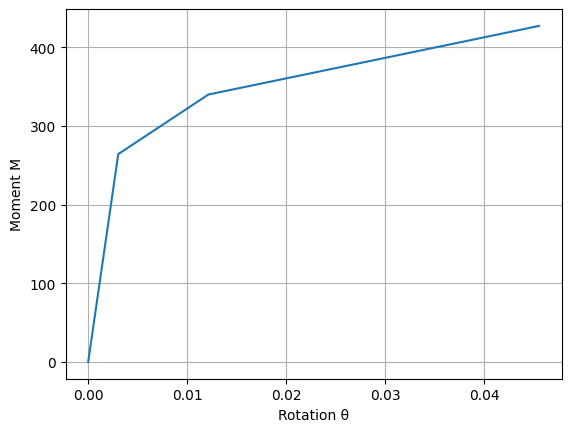

M1yp 264.18700308 M2yp 339.91794408 M3yP 427.09965509639994
g1 0.0030377644110275697 g2 0.012151057644110279 g3 0.045566466165413544
Ke= 422172.69230769225
KnP= 40339525.76549663
KnN= 40339525.76549663
Panel zone Hysteretic backbone points:
  M1yP = 264.2 kNm at γ1 = 3.04 mrad
  M2yP = 339.9 kNm at γ2 = 12.15 mrad
  M3yP = 427.1 kNm at γ3 = 45.57 mrad
Panel zone 101:
  Hysteretic mat: 4010140
  Element: 4010100
  Limits: -0.3000 to 0.3000 rad
  Limits: -300.0 to 300.0 mrad
dc (SECCOLMN.h) = 300.0
d (SECCOLMN.d) = 262.0
dpos (SECBEAMX.dpos) = 206.0
tp = 21.0
Vy = 1282461.1800000002
Ke (before 1e-3) = 422172.69230769225


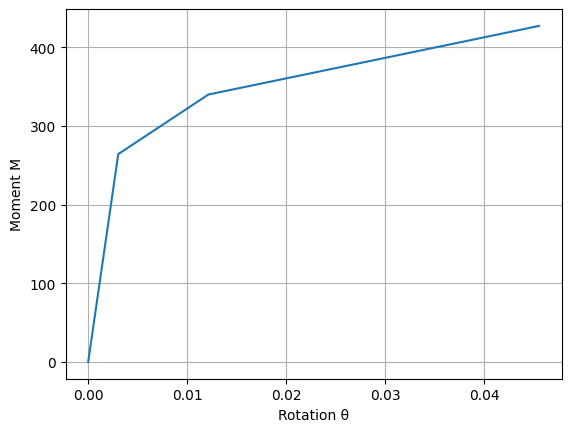

M1yp 264.18700308 M2yp 339.91794408 M3yP 427.09965509639994
g1 0.0030377644110275697 g2 0.012151057644110279 g3 0.045566466165413544
Ke= 422172.69230769225
KnP= 40339525.76549663
KnN= 40339525.76549663
Panel zone Hysteretic backbone points:
  M1yP = 264.2 kNm at γ1 = 3.04 mrad
  M2yP = 339.9 kNm at γ2 = 12.15 mrad
  M3yP = 427.1 kNm at γ3 = 45.57 mrad
Panel zone 301:
  Hysteretic mat: 4030140
  Element: 4030100
  Limits: -0.3000 to 0.3000 rad
  Limits: -300.0 to 300.0 mrad
dc (SECCOLMN.h) = 300.0
d (SECCOLMN.d) = 262.0
dpos (SECBEAMX.dpos) = 206.0
tp = 21.0
Vy = 1282461.1800000002
Ke (before 1e-3) = 422172.69230769225


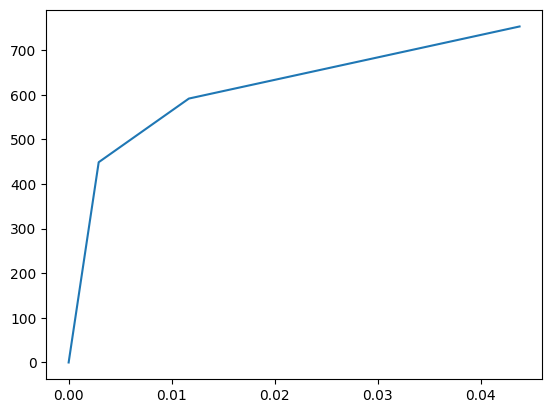

In [20]:
#Panel Zone
Unitsmulti=1e-3 
#before anything else 
Construct_Panel(101,SecbeamX,SecColmn,I_panel,A_panel,Pdelta1,Unitsmulti)
Construct_Panel(201,SecbeamX,SecColmn,I_panel,A_panel,Pdelta1,Unitsmulti)
Construct_Panel(301,SecbeamX,SecColmn,I_panel,A_panel,Pdelta1,Unitsmulti)
#Panelzone Springs
Spring_Panel_Kraw(101,SecbeamX,SecColmn,41,SH_Panel,G,1,10)
#Spring_Panel_Kraw(201,SecbeamX,SecColmn,42,SH_Panel,G,2,10)
Spring_Panel_Kraw(301,SecbeamX,SecColmn,43,SH_Panel,G,1,10)
#Spring_Panel_KrawBilin(101,SecbeamX,SecColmn,41,SH_Panel,G,1,10)
#Spring_Panel_KrawBilin(201,SecbeamX,SecColmn,42,SH_Panel,G,2,10)
#Spring_Panel_KrawBilin(301,SecbeamX,SecColmn,43,SH_Panel,G,1,10)
#Spring_Panel_LgSk(101,SecbeamX,SecColmn,41,SH_Panel,G,1,10)
Spring_Panel_LgSk(201,SecbeamX,SecColmn,42,SH_Panel,G,2,10)
#Spring_Panel_LgSk(301,SecbeamX,SecColmn,43,SH_Panel,G,1,10)
#Spring_Panel_Manual(101,SecbeamX,SecColmn,41,SH_Panel,G,1,10)
#Spring_Panel_Manual(201,SecbeamX,SecColmn,42,SH_Panel,G,2,10)
#Spring_Panel_Manual(301,SecbeamX,SecColmn,43,SH_Panel,G,1,10)
#Spring_Panel_Kim(101,SecbeamX,SecColmn,41,SH_Panel,G,1,10)
#Spring_Panel_Kim(201,SecbeamX,SecColmn,42,SH_Panel,G,2,10)
#Spring_Panel_Kim(301,SecbeamX,SecColmn,43,SH_Panel,G,1,10)


In [21]:
gamma_lp=(((fy_beam_fl+fy_beam_web)/2)/250)**0.5
kf=(SecbeamX.b)/(2*SecbeamX.tf)*gamma_lp/9
kw=(SecbeamX.d/SecbeamX.tw)*gamma_lp/70
kd=1
r=SecbeamX.b/(2*3*0.5)
laeff=kf*kw*kd*gamma_lp*((0.5*Gridops.Xbay_stval*1e3)/r)
Lp_kemp=0.067*0.5*Gridops.Xbay_stval*(60/laeff)**1.5
print(Lp_kemp)
print(Gridops.Xbay_stval/16)
Lp_kemp=round(Lp_kemp,2)

8.397242834062205e-08
0.3125


In [22]:
#Connections 
#Connections Before Hinges !
nodeEQ_DOF_notation(101,9,4,(1,2))
nodeEQ_DOF_notation(201,9,2,(1,2))
nodeEQ_DOF_notation(201,9,4,(1,2))
nodeEQ_DOF_notation(301,9,2,(1,2))
#Connections springs
ops.element('zeroLength',9010104,410104,910104,'-mat',90,'-dir',3)
ops.element('zeroLength',9020102,420102,920102,'-mat',90,'-dir',3)
ops.element('zeroLength',9020104,420104,920104,'-mat',90,'-dir',3)
ops.element('zeroLength',9030102,430102,930102,'-mat',90,'-dir',3)
###################################################################
#ops.element('zeroLength',9010104,410104,910104,'-mat',91,'-dir',3)
#ops.element('zeroLength',9020102,420102,920102,'-mat',91,'-dir',3)
#ops.element('zeroLength',9020104,420104,920104,'-mat',91,'-dir',3)
#ops.element('zeroLength',9030102,430102,930102,'-mat',91,'-dir',3)

Conection Nodes:
-Master Node 410104
-Slave Node 910104
Conection Nodes:
-Master Node 420102
-Slave Node 920102
Conection Nodes:
-Master Node 420104
-Slave Node 920104
Conection Nodes:
-Master Node 430102
-Slave Node 930102


Beam Concentrated Plasticity Nodes Start:
-Master Node through rigid ele with Lp offset 910104
-Offset Lp Node 610104
Beam Concentrated Plasticity Nodes End:
-Master Node Start Hinge 610104
-Slave Node 610144
Beam Concentrated Plasticity Nodes Start:
-Master Node through rigid ele with Lp offset 920102
-Offset Lp Node 620102
Beam Concentrated Plasticity Nodes End:
-Master Node Start Hinge 620102
-Slave Node 620122
Beam Concentrated Plasticity Nodes Start:
-Master Node through rigid ele with Lp offset 920104
-Offset Lp Node 620104
Beam Concentrated Plasticity Nodes End:
-Master Node Start Hinge 620104
-Slave Node 620144
Beam Concentrated Plasticity Nodes Start:
-Master Node through rigid ele with Lp offset 930102
-Offset Lp Node 630102
Beam Concentrated Plasticity Nodes End:
-Master Node Start Hinge 630102
-Slave Node 630122
Python version of IMK with Section databases updated for new Bilin by GR 
thp pre adj 0.015241870828113395
IMKBilin updated Version
My 318.80497302127657 K 215190.3

IMK with Bilinear Response - Code by AE_KI (Nov22)


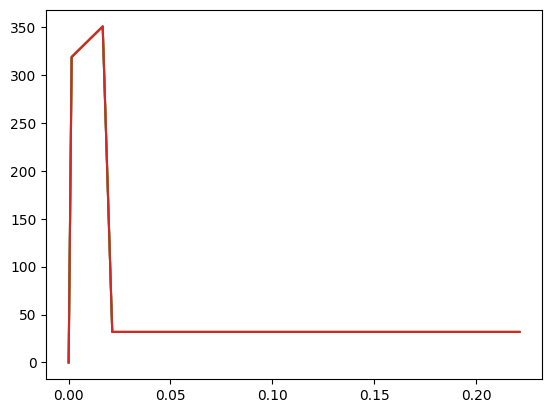

In [23]:

#Beam Elements 
#element('elasticBeamColumn', eleTag, *eleNodes, Area, E_mod, Iz, transfTag, <'-mass', mass>, <'-cMass'>, <'-release', releaseCode>)
#element('elasticBeamColumn', eleTag, *eleNodes, secTag, transfTag, <'-mass', mass>, <'-cMass'>, <'-release', releaseCode>)
# BEAM HINGE 600XAYAZA0i TO OPPOSITE SIDE 600 XBYBZB0i
Unitsmulti=1e-3
#From i to j Naming  origin tag i 
if Hinges ==1:
    #Beams
    nodeEQ_DOF_notation(101,6,4,(1,2))
    nodeEQ_DOF_notation(201,6,2,(1,2))
    nodeEQ_DOF_notation(201,6,4,(1,2))
    nodeEQ_DOF_notation(301,6,2,(1,2))
    #ops.equalDOF(410104,610104,3)
    #ops.equalDOF(420102,620102,3)
    #ops.equalDOF(420104,620104,3)
    #ops.equalDOF(430102,630102,3)

    #ops.equalDOF(410104,910104,3)
    #ops.equalDOF(420102,920102,3)
    #ops.equalDOF(420104,920104,3)
    #ops.equalDOF(430102,930102,3)





    ops.element('elasticBeamColumn', 60010104, *[610144,620122],SecbeamX.A*Unitsmulti**2,E*1e3,SecbeamX.Iy*Unitsmulti**4, SecbeamX.geotransfTag)#,'-release',3
    ops.element('elasticBeamColumn', 60020104, *[620144,630122],SecbeamX.A*Unitsmulti**2,E*1e3,SecbeamX.Iy*Unitsmulti**4, SecbeamX.geotransfTag)#,'-release',3
    if Actuator!=0:
    #Actuator beams
        ops.element('elasticBeamColumn',1,*[102,202],SecBeamActuator.A*Unitsmulti**2,E*1e3,SecBeamActuator.Iy*Unitsmulti**4,Pdelta1)
        ops.element('elasticBeamColumn',2,*[202,302],SecBeamActuator.A*Unitsmulti**2,E*1e3,SecBeamActuator.Iy*Unitsmulti**4,Pdelta1)
    ########### Rigid offet to Beam PH
    #for different material choose the second definition for elasticBeamColumn through Sections
    #ops.element('elasticBeamColumn',961,9010104,6010104,SecbeamX.A*Unitsmulti**2,E,SecbeamX.Iy*Unitsmulti**4,1)
    #ops.element('elasticBeamColumn',962,9020102,6020102,SecbeamX.A*Unitsmulti**2,E,SecbeamX.Iy*Unitsmulti**4,1)
    #ops.element('elasticBeamColumn',963,9020104,6020104,SecbeamX.A*Unitsmulti**2,E,SecbeamX.Iy*Unitsmulti**4,1)
    #ops.element('elasticBeamColumn',964,9030102,6030102,SecbeamX.A*Unitsmulti**2,E,SecbeamX.Iy*Unitsmulti**4,1)
    #rig

    ops.element('elasticBeamColumn',961,910104,610104,A_panel,E*1e3,I_panel,1)#,'-release',3
    ops.element('elasticBeamColumn',962,920102,620102,A_panel,E*1e3,I_panel,1)#,'-release',3
    ops.element('elasticBeamColumn',963,920104,620104,A_panel,E*1e3,I_panel,1)#,'-release',3
    ops.element('elasticBeamColumn',964,930102,630102,A_panel,E*1e3,I_panel,1)#,'-release',3
    #IMK Springs for Beams 
    Spring_IMK(6010104,61014,610104,610144,SecbeamX,E,fy_beam,'y-y',Gridops.Xbay_stval,Gridops.Xbay_stval,0,0,1,3)
    Spring_IMK(6020102,62012,620102,620122,SecbeamX,E,fy_beam,'y-y',Gridops.Xbay_stval,Gridops.Xbay_stval,0,0,1,3)
    Spring_IMK(6020104,62014,620104,620144,SecbeamX,E,fy_beam,'y-y',Gridops.Xbay_stval,Gridops.Xbay_stval,0,0,1,3)
    Spring_IMK(6030102,63012,630102,630122,SecbeamX,E,fy_beam,'y-y',Gridops.Xbay_stval,Gridops.Xbay_stval,0,0,1,3)
elif Hinges==0:
    if NonlinearBeamCol!=1:
        #option for no Ph at ends 
        ops.element('elasticBeamColumn', 60010104, *[910104,920102],SecbeamX.A*Unitsmulti**2,E*1e3,SecbeamX.Iy*Unitsmulti**4, SecbeamX.geotransfTag)
        ops.element('elasticBeamColumn', 60020104, *[920104,930102],SecbeamX.A*Unitsmulti**2,E*1e3,SecbeamX.Iy*Unitsmulti**4, SecbeamX.geotransfTag)
    if NonlinearBeamCol==1:
        #I_sec_fiber(SECTAG,E,SECTION,GJ,MAT_TAG_FL,MAT_TAG_WEB,MP)
        I_sec_fiber(666,E,SecbeamX,GJ,36,361,108)
        ops.section('Elastic',360,E*1e3, SecbeamX.A*Unitsmulti**2,SecbeamX.Iy*Unitsmulti**4)

        ops.element('beamWithHinges',60010104,*[910104,920102],666,Lp_kemp,666,Lp_kemp,E*1e3,SecbeamX.A*Unitsmulti**2,SecbeamX.Iy*Unitsmulti**4,1)
        ops.beamIntegration('HingeRadauTwo',17,666,Lp_kemp,666,Lp_kemp,360)
        ops.element('beamWithHinges',60020104,*[920104,930102],666,Lp_kemp,666,Lp_kemp,E*1e3,SecbeamX.A*Unitsmulti**2,SecbeamX.Iy*Unitsmulti**4,1)
        ops.beamIntegration('HingeRadauTwo',18,666,Lp_kemp,666,Lp_kemp,360)
        #ops.beamIntegration('Radau',71,666,10)
        #ops.element('forceBeamColumn',60010104,*[910104,920102],1,71)
        #ops.element('forceBeamColumn',60020104,*[920104,930102],1,71)

    if Actuator!=0:
        #Actuator beams
        ops.element('elasticBeamColumn',1,*[102,202],SecBeamActuator.A*Unitsmulti**2,E*1e3,SecBeamActuator.Iy*Unitsmulti**4,Pdelta1)
        ops.element('elasticBeamColumn',2,*[202,302],SecBeamActuator.A*Unitsmulti**2,E*1e3,SecBeamActuator.Iy*Unitsmulti**4,Pdelta1)


Column Concentrated Plasticity Nodes:
-Master Node 410101
-Slave Node 510101
Column Concentrated Plasticity Nodes:
-Master Node 420101
-Slave Node 520101
Column Concentrated Plasticity Nodes:
-Master Node 430101
-Slave Node 530101
Column Concentrated Plasticity Nodes:
-Master Node 410103
-Slave Node 510103
Column Concentrated Plasticity Nodes:
-Master Node 420103
-Slave Node 520103
Column Concentrated Plasticity Nodes:
-Master Node 430103
-Slave Node 530103
Python version of IMK with Section databases updated for new Bilin by GR 
thp pre adj 0.2
IMKBilin updated Version
My 779.339334021082 K 2491830.0 thp 0.19896789917359148 thpc 0.304472436914437
Python version of IMK with Section databases updated for new Bilin by GR 
thp pre adj 0.2
IMKBilin updated Version
My 779.4120079269956 K 2491830.0 thp 0.19896780292951002 thpc 0.3044728539721233
Python version of IMK with Section databases updated for new Bilin by GR 
thp pre adj 0.2
IMKBilin updated Version
My 778.7665559774367 K 2491830.0 

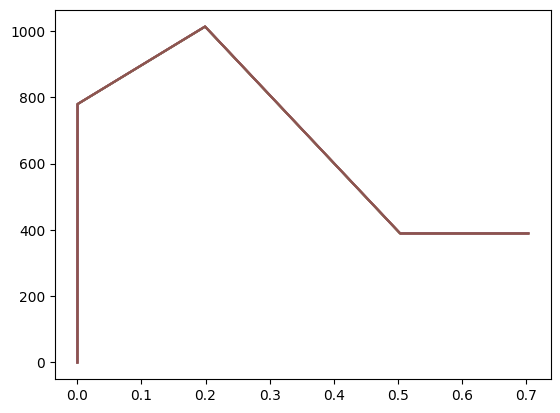

In [ ]:
if Hinges==1:
    if Base==1:
        #Base Connection
        nodeEQ_DOF_notation(100,7,3,(1,2))
        nodeEQ_DOF_notation(200,7,3,(1,2))
        nodeEQ_DOF_notation(300,7,3,(1,2))


    ########### Columns #####################################
    #bottoms
    nodeEQ_DOF_notation(101,5,1,(1,2))
    nodeEQ_DOF_notation(201,5,1,(1,2))
    nodeEQ_DOF_notation(301,5,1,(1,2))
    #tops
    nodeEQ_DOF_notation(101,5,3,(1,2))
    nodeEQ_DOF_notation(201,5,3,(1,2))
    nodeEQ_DOF_notation(301,5,3,(1,2))
    Unitsmulti=1e-3
    #IMK Springs for Columns
    if Base==1:
        #Spring_IMK(SpringID, Node_i, Node_j,SECTION,E, Fy, Ix,ix,L,Lb,PgPye,CompositeFLAG,ConnectionType,dof
        Spring_IMK(7010003,51003,   100,710003,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg100_Py,0,2,3)
        Spring_IMK(5010101,51011,510101,410101,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg10101_Py,0,2,3)
        Spring_IMK(5010103,51013,410103,510103,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg10103_Py,0,2,3)
        #
        Spring_IMK(7020003,52003,    200,720003,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg200_Py,0,2,3)
        Spring_IMK(5020101,52011,520101,420101,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg20101_Py,0,2,3)
        Spring_IMK(5020103,52013,420103,520103,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg20103_Py,0,2,3)
        #
        Spring_IMK(7030003,53003,   300,730003,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg300_Py,0,2,3)
        Spring_IMK(5030101,53011,530101,430101,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg30101_Py,0,2,3)
        Spring_IMK(5030103,53013,430103,530103,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg30103_Py,0,2,3)
    else:
        #Spring_IMK(SpringID, Node_i, Node_j,SECTION,E, Fy, Ix,ix,L,Lb,PgPye,CompositeFLAG,ConnectionType,dof
        Spring_IMK(5010101,51011,510101,410101,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg10101_Py,0,2,3)
        Spring_IMK(5010103,51013,410103,510103,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg10103_Py,0,2,3)
        #
        Spring_IMK(5020101,52011,520101,420101,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg20101_Py,0,2,3)
        Spring_IMK(5020103,52013,420103,520103,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg20103_Py,0,2,3)
        #
        Spring_IMK(5030101,53011,530101,430101,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg30101_Py,0,2,3)
        Spring_IMK(5030103,53013,430103,530103,SecColmn,E,fy_col,'y-y',Gridops.Hbay_stval,Gridops.Hbay_stval,Pg30103_Py,0,2,3)
    #COL ELEMENTS
    if Base==1:
    #From i to j Naming  origin tag i 
        #Tags for easier code 17 base conn spring is skipped and the node tag  of the 'original' bc is used  
        ops.element('elasticBeamColumn', 50010003, *[710003,510101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',3
        ops.element('elasticBeamColumn', 50010103, *[510103,   102],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',1
        ops.element('elasticBeamColumn', 50020003, *[720003,520101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',3
        ops.element('elasticBeamColumn', 50020103, *[520103,   202],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',1
        ops.element('elasticBeamColumn', 50030003, *[730003,530101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',3
        ops.element('elasticBeamColumn', 50030103, *[530103,   302],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',1
    else:
        #Tags for easier code 17 base conn spring is skipped and the node tag  of the 'original' bc is used  
        ops.element('elasticBeamColumn', 50010003, *[100,510101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',3
        ops.element('elasticBeamColumn', 50010103, *[510103,102],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',1
        ops.element('elasticBeamColumn', 50020003, *[200,520101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',3
        ops.element('elasticBeamColumn', 50020103, *[520103,202],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',1
        ops.element('elasticBeamColumn', 50030003, *[300,530101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',3
        ops.element('elasticBeamColumn', 50030103, *[530103,   302],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#,'-release',1
elif Hinges==0:
    #COL ELEMENTS
    #From i to j Naming  origin tag i 
    #Tags for easier code 17 base conn spring is skipped and the node tag  of the 'original' bc is used  
    ops.element('elasticBeamColumn', 50010003, *[100,410101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)
    ops.element('elasticBeamColumn', 50010103, *[410103,102],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#'-release',2
    ops.element('elasticBeamColumn', 50020003, *[200,420101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)# 
    ops.element('elasticBeamColumn', 50020103, *[420103,202],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#'-release',2
    ops.element('elasticBeamColumn', 50030003, *[300,430101],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)# 
    ops.element('elasticBeamColumn', 50030103, *[430103,302],SecColmn.A*Unitsmulti**2,E*1e3,SecColmn.Iy*Unitsmulti**4, SecColmn.geotransfTag)#'-release',2

        #I_sec_fiber(555,E,SecColmn,GJ,35,351,108)
        #ops.beamIntegration('Radau',75,555,10)
        #ops.element('forceBeamColumn',50010003,*[100,410101],1,75)
        #ops.element('forceBeamColumn',50010103,*[410103,102],1,75) etc....

# 12 Gravity loads and control
analysis options for gravity    
application of distributed loads and point loads due to the actuator    
creation of recorders for each specimen of choice for gravity analysis  
all loads in opensees are applied gradually in a load rate and not instantly as the algorythm solving the equations need to converge numerically    
output options for visual control mainly in case a specimen has wrong units and has irregular stiffness     
quick check of reactions to confirm the load appliance 

In [25]:


##  case gravity
#Set constants time etc
#time series (start of clock), tag
ops.timeSeries("Constant",1)
#pattern type others are uniform Excitation and multipositional excitation 
ops.pattern("Plain",1,1)
#Gravity Loads applied 
g=9.81
Unitsmulti=1e-3
#eleLoad('-ele',*eleTags,'-range',eleTag1,eleTag2,'-type','-beamUniform',Wy,<Wz>,Wx=0.0,'-beamPoint',Py,<Pz>,xL,Px=0.0,'-beamThermal',*tempPts)
#beams
ops.eleLoad('-ele',*(60010104,60020104),'-type','-beamUniform',-SecbeamX.m*g*Unitsmulti,0.0)
if Actuator==0:
    ops.load(102,0,-R1top,0)
    ops.load(202,0,-R2top,0)
    ops.load(302,0,-R1top,0)
else:
    #actuator beams 
    ops.eleLoad('-ele',*(1,2),'-type','-beamUniform',-SecBeamActuator.m*g*Unitsmulti,0.0)
#columns
ops.eleLoad('-ele',*(50010003,50020003,50030003,50010103,50020103,50030103),'-type','-beamUniform',0.0,-SecColmn.m*g*Unitsmulti)

#integrator for 
ops.integrator("LoadControl", 0.01)
#way matrices are defined 
ops.system("SparseGeneral","-piv")    # Overkill, but may need the pivoting!
#test type tol iter  pflag(4=each step)
ops.test("NormUnbalance", 1e-5, 1000, 1)
ops.numberer("Plain")
ops.constraints("Transformation")
#algorithm ModifiedNewton -initial
ops.algorithm("Newton")
ops.analysis("Static")
ops.analyze(100)
if not os.path.exists(SubPath):
    os.makedirs(SubPath)
An=1
def Rfile(name):
    return os.path.join(SubPath, name)
#Panelzone
#moment
gmoment4010100=open(Rfile('g4010100moment.txt'),'w')
gmoment4020100=open(Rfile('g4020100moment.txt'),'w')
gmoment4030100=open(Rfile('g4030100moment.txt'),'w')
#thetas
gthetas4010100=open(Rfile('g4010100thetas'),'w')
gthetas4020100=open(Rfile('g4020100thetas'),'w')
gthetas4030100=open(Rfile('g4030100thetas'),'w')
#Connentions
#moment
gmoment9010104=open(Rfile('g9010104moment.txt'),'w')
gmoment9020102=open(Rfile('g9020102moment.txt'),'w')
gmoment9020104=open(Rfile('g9020104moment.txt'),'w')
gmoment9030102=open(Rfile('g9030102moment.txt'),'w')
#thetas
gthetas9010104=open(Rfile('g9010104thetas.txt'),'w')
gthetas9020102=open(Rfile('g9020102thetas.txt'),'w')
gthetas9020104=open(Rfile('g9020104thetas.txt'),'w')
gthetas9030102=open(Rfile('g9030102thetas.txt'),'w')
#Beams
#moment
gmoment6010104=open(Rfile('g6010104moment.txt'),'w')
gmoment6020102=open(Rfile('g6020102moment.txt'),'w')
gmoment6020104=open(Rfile('g6020104moment.txt'),'w')
gmoment6030102=open(Rfile('g6030102moment.txt'),'w')
#thetas
gthetas6010104=open(Rfile('g6010104thetas.txt'),'w')
gthetas6020102=open(Rfile('g6020102thetas.txt'),'w')
gthetas6020104=open(Rfile('g6020104thetas.txt'),'w')
gthetas6030102=open(Rfile('g6030102thetas.txt'),'w')
ops.loadConst("-time", 0.0)
i=1
while i<=100:
    ops.analyze(1)
    M_moment = ops.eleResponse(4010100, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(4010100, 'material', 1, 'strain')[0]
    gmoment4010100.write(f"{M_moment}\n")
    gthetas4010100.write(f"{M_thetas}\n")
    M_moment = ops.eleResponse(4020100, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(4020100, 'material', 1, 'strain')[0]
    gmoment4020100.write(f"{M_moment}\n")
    gthetas4020100.write(f"{M_thetas}\n")
    M_moment = ops.eleResponse(4030100, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(4030100, 'material', 1, 'strain')[0]
    gmoment4030100.write(f"{M_moment}\n")
    gthetas4030100.write(f"{M_thetas}\n")
    #Conn
    M_moment = ops.eleResponse(9010104, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(9010104, 'material', 1, 'strain')[0]
    gmoment9010104.write(f"{M_moment}\n")
    gthetas9010104.write(f"{M_thetas}\n")
    M_moment = ops.eleResponse(9020102, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(9020102, 'material', 1, 'strain')[0]
    gmoment9020102.write(f"{M_moment}\n")
    gthetas9020102.write(f"{M_thetas}\n")
    M_moment = ops.eleResponse(9020104, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(9020104, 'material', 1, 'strain')[0]
    gmoment9020104.write(f"{M_moment}\n")
    gthetas9020104.write(f"{M_thetas}\n")
    M_moment = ops.eleResponse(9030102, 'material', 1, 'stress')[0]
    M_thetas = ops.eleResponse(9030102, 'material', 1, 'strain')[0]
    gmoment9030102.write(f"{M_moment}\n")
    gthetas9030102.write(f"{M_thetas}\n")
    #beams
    if Hinges==1:
        M_moment = ops.eleResponse(6010104, 'material', 1, 'stress')[0]
        M_thetas = ops.eleResponse(6010104, 'material', 1, 'strain')[0]
        gmoment6010104.write(f"{M_moment}\n")
        gthetas6010104.write(f"{M_thetas}\n")
        M_moment = ops.eleResponse(6020102, 'material', 1, 'stress')[0]
        M_thetas = ops.eleResponse(6020102, 'material', 1, 'strain')[0]
        gmoment6020102.write(f"{M_moment}\n")
        gthetas6020102.write(f"{M_thetas}\n")
        M_moment = ops.eleResponse(6020104, 'material',1, 'stress')[0]
        M_thetas = ops.eleResponse(6020104, 'material',1, 'strain')[0]
        gmoment6020104.write(f"{M_moment}\n")
        gthetas6020104.write(f"{M_thetas}\n")
        M_moment = ops.eleResponse(6030102, 'material',1, 'stress')[0]
        M_thetas = ops.eleResponse(6030102, 'material',1,'strain')[0]
        gmoment6030102.write(f"{M_moment}\n")
        gthetas6030102.write(f"{M_thetas}\n")
    i=i+1
print('Load Pattern 1 Gravity Time series 1 Done ')
gmoment4010100.close()
gmoment4020100.close()
gmoment4030100.close()
gmoment9010104.close()
gmoment9020102.close()
gmoment9020104.close()
gmoment9030102.close()
gmoment6010104.close()
gmoment6020102.close()
gmoment6020104.close()
gmoment6030102.close()




CTestNormUnbalance::test() - iteration: 1 current Norm: 0.000221012 (max: 1e-05, Norm deltaX: 0.000108518)
CTestNormUnbalance::test() - iteration: 2 current Norm: 3.3795e-07 (max: 1e-05, Norm deltaX: 3.44349e-09)

CTestNormUnbalance::test() - iteration: 1 current Norm: 5.27337e-07 (max: 1e-05, Norm deltaX: 1.17328e-14)

CTestNormUnbalance::test() - iteration: 1 current Norm: 4.47552e-07 (max: 1e-05, Norm deltaX: 3.14539e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 2.88724e-07 (max: 1e-05, Norm deltaX: 2.7919e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 3.94356e-07 (max: 1e-05, Norm deltaX: 3.0525e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 3.97445e-07 (max: 1e-05, Norm deltaX: 2.88481e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 5.5345e-07 (max: 1e-05, Norm deltaX: 2.78136e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 4.73415e-07 (max: 1e-05, Norm deltaX: 3.01667e-18)

CTestNormUnbalance::test() - iter

Load Pattern 1 Gravity Time series 1 Done 


CTestNormUnbalance::test() - iteration: 1 current Norm: 4.96195e-07 (max: 1e-05, Norm deltaX: 2.599e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 5.95598e-07 (max: 1e-05, Norm deltaX: 2.96965e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 4.74599e-07 (max: 1e-05, Norm deltaX: 2.49937e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 3.81354e-07 (max: 1e-05, Norm deltaX: 2.8629e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 4.26626e-07 (max: 1e-05, Norm deltaX: 2.48532e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 3.33178e-07 (max: 1e-05, Norm deltaX: 2.81165e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 5.49666e-07 (max: 1e-05, Norm deltaX: 2.78953e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 4.57243e-07 (max: 1e-05, Norm deltaX: 2.64089e-18)

CTestNormUnbalance::test() - iteration: 1 current Norm: 6.15865e-07 (max: 1e-05, Norm deltaX: 2.6905e-18)

CTestNormUnbalance::test() - ite

Current Domain Information
	Current Time: 1
	Committed Time: 1
NODE DATA: NumNodes: 60

numComponents: 60

 Node: 100
	Coordinates  : 0 0 
	Disps: 0 0 3.6578e-06 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 0 


 Node: 102
	Coordinates  : 0 2.8 
	Disps: 1.44289e-05 -3.93827e-06 -8.22719e-06 
	 unbalanced Load: 0 -2.6373 0 
	ID : 1 2 3 


 Node: 200
	Coordinates  : 5 0 
	Disps: 0 0 -2.78021e-10 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 4 


 Node: 202
	Coordinates  : 5 2.8 
	Disps: 7.20186e-10 -9.65943e-06 -2.83589e-10 
	 unbalanced Load: 0 -8.79099 0 
	ID : 5 6 7 


 Node: 300
	Coordinates  : 10 0 
	Disps: 0 0 -3.65833e-06 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 8 


 Node: 302
	Coordinates  : 10 2.8 
	Disps: -1.44275e-05 -3.93827e-06 8.22666e-06 
	 unbalanced Load: 0 -2.6373 0 
	ID : 9 10 11 


 Node: 410101
	Coordinates  : 0 1.297 
	Disps: 2.31108e-07 -2.53729e-06 -8.22659e-06 
	Velocities   : 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : 12 13 14 


 Node: 410102
	Coordinates  : -0.131 1.4 
	Disps: 

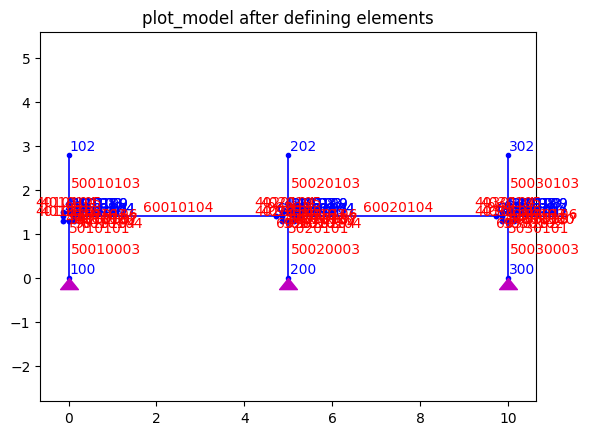

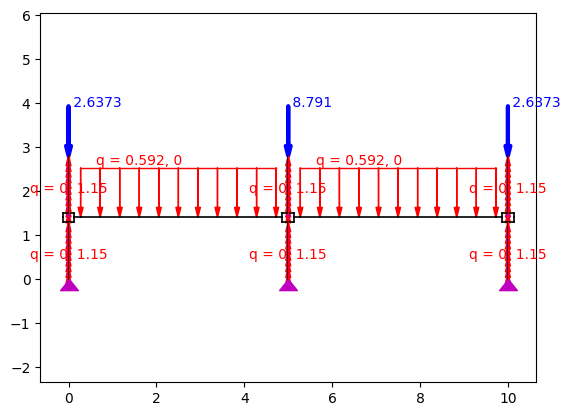

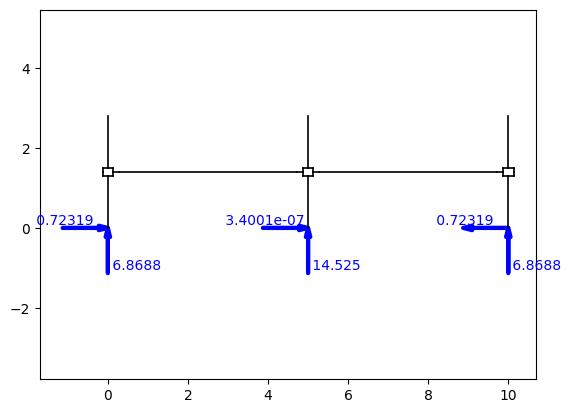

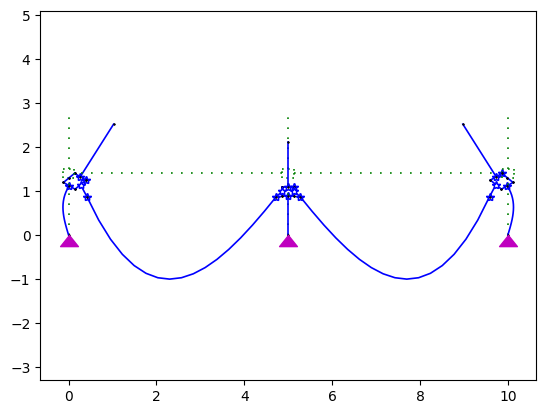

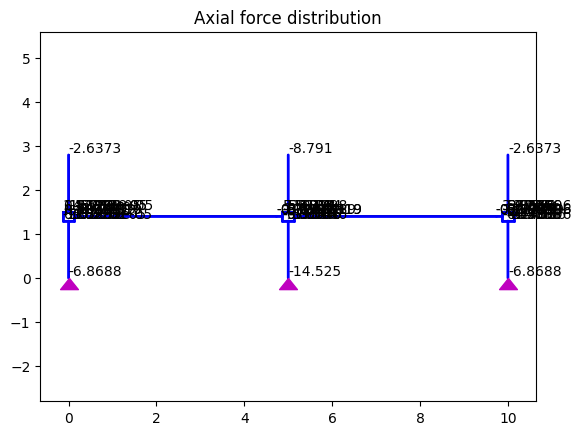

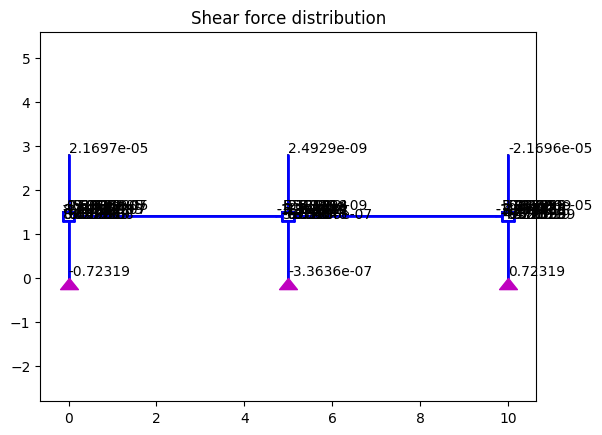

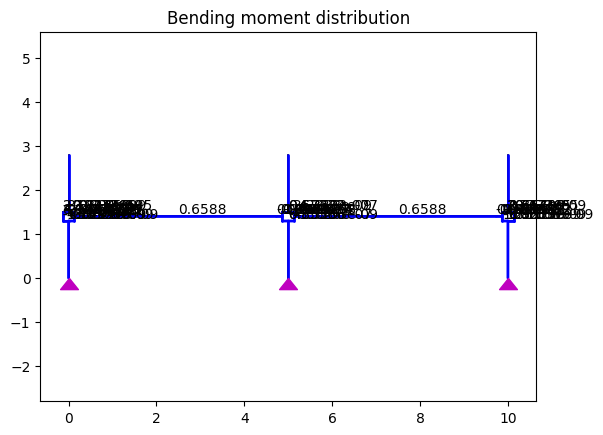

In [26]:
ops.printModel()

opsv.plot_model()
plt.title('plot_model after defining elements')

opsv.plot_load()

opsv.plot_reactions()

# sfac = 80.

opsv.plot_defo()
# opsv.plot_defo(sfac)
# fmt_interp = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
# opsv.plot_defo(sfac, fmt_interp=fmt_interp)

# 4. plot N, V, M forces diagrams

sfacN, sfacV, sfacM = 5.e-5, 5.e-5, 5.e-5

opsv.section_force_diagram_2d('N', sfacN)
plt.title('Axial force distribution')

opsv.section_force_diagram_2d('T', sfacV)
plt.title('Shear force distribution')

opsv.section_force_diagram_2d('M', sfacM)
plt.title('Bending moment distribution')

plt.show()


In [27]:

ops.nodeReaction(100)
for n in ops.getNodeTags():
    rx, ry, rz = ops.nodeReaction(n)
    print(f"Node {n} reactions: FX={rx:.3f}, FY={ry:.3f}, MZ={rz:.3f}")
    rx, ry, rz = ops.nodeDisp(n)
    print(f"Node {n} disp: dX={rx:.3f}, dY={ry:.3f}, dZ={rz:.3f}")

Node 100 reactions: FX=0.723, FY=6.869, MZ=0.000
Node 100 disp: dX=0.000, dY=0.000, dZ=0.000
Node 102 reactions: FX=0.000, FY=0.000, MZ=0.000
Node 102 disp: dX=0.000, dY=-0.000, dZ=-0.000
Node 200 reactions: FX=0.000, FY=14.525, MZ=0.000
Node 200 disp: dX=0.000, dY=0.000, dZ=-0.000
Node 202 reactions: FX=0.000, FY=0.000, MZ=0.000
Node 202 disp: dX=0.000, dY=-0.000, dZ=-0.000
Node 300 reactions: FX=-0.723, FY=6.869, MZ=0.000
Node 300 disp: dX=0.000, dY=0.000, dZ=-0.000
Node 302 reactions: FX=-0.000, FY=0.000, MZ=-0.000
Node 302 disp: dX=-0.000, dY=-0.000, dZ=0.000
Node 410101 reactions: FX=0.723, FY=5.380, MZ=-0.000
Node 410101 disp: dX=0.000, dY=-0.000, dZ=-0.000
Node 410102 reactions: FX=0.000, FY=0.000, MZ=-0.000
Node 410102 disp: dX=0.000, dY=-0.000, dZ=-0.000
Node 410103 reactions: FX=0.000, FY=-4.126, MZ=-0.000
Node 410103 disp: dX=0.000, dY=-0.000, dZ=-0.000
Node 410104 reactions: FX=-0.723, FY=-1.254, MZ=-0.000
Node 410104 disp: dX=0.000, dY=-0.000, dZ=-0.000
Node 410105 reactio

# 13 Cyclic Load Protocol analysis 
loading of data   and filter of same values 
Cyclic analysis values again as per the experiment the control is based on displacement in the control node disp    
recorders workaround requires recording at each analysis step 
     

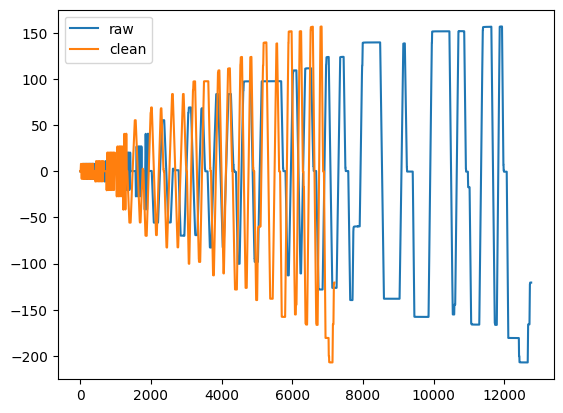

12760 raw
7192 clean
Smallest increment: 2.431869e-08
Largest increment: 6.413441e+00


In [28]:
#Cyclic data load 
from openpyxl import load_workbook
data_len=12766
data_start=7
wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
with open("Displacement_Cyclic_SP_S2.txt", "w", encoding="utf-8") as f:
    for row in ws.iter_rows(
            values_only=True,
            min_row=data_start,
            max_row=data_len,
            min_col=1,
            max_col=1,
    ):
        line = "\t".join("" if v is None else str(v) for v in row)
        f.write(line + "\n")

Displacements_Cyclic = np.loadtxt('Displacement_Cyclic_SP_S2.txt')

mask = np.ones(len(Displacements_Cyclic), dtype=bool)
mask[1:] = Displacements_Cyclic[1:] != Displacements_Cyclic[:-1]

Displacements_Cyclic_clean = Displacements_Cyclic[mask]

plt.plot(Displacements_Cyclic, label="raw")
plt.plot(Displacements_Cyclic_clean, label="clean")
plt.legend()
plt.show()
with open('Displacements_Cyclic_clean.txt', "w") as f:
    # Optionally, write a header
    f.write("# Step\tDisplacement\n")
    for step, d in enumerate(Displacements_Cyclic_clean, start=1):
        f.write(f"{step}\t{d:.12e}\n")
print(len(Displacements_Cyclic), "raw")
print(len(Displacements_Cyclic_clean), "clean")
increments = np.diff(Displacements_Cyclic_clean)

# Find minimum and maximum increment
min_inc = np.min(np.abs(increments))
max_inc = np.max(np.abs(increments))

print(f"Smallest increment: {min_inc:.6e}")
print(f"Largest increment: {max_inc:.6e}")

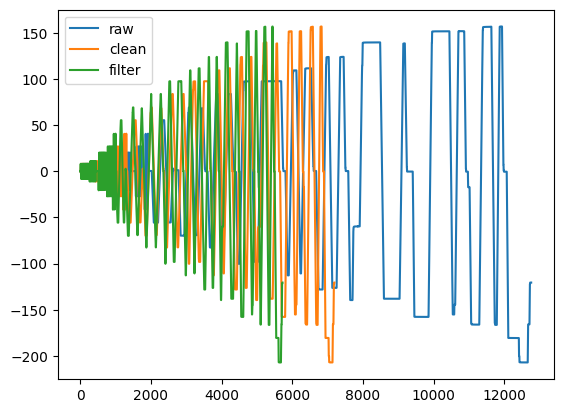

In [ ]:
plt.plot(Displacements_Cyclic, label="raw")
plt.plot(Displacements_Cyclic_clean, label="clean")
plt.legend()
plt.show()

In [ ]:
ops.wipeAnalysis()

An=1#analysis type 
Happ=1

#Panelzone
#moment
moment4010100=open(Rfile('4010100moment.txt'),'w')
moment4020100=open(Rfile('4020100moment.txt'),'w')
moment4030100=open(Rfile('4030100moment.txt'),'w')
#thetas
thetas4010100=open(Rfile('4010100thetas.txt'),'w')
thetas4020100=open(Rfile('4020100thetas.txt'),'w')
thetas4030100=open(Rfile('4030100thetas.txt'),'w')
#Connentions
#moment
moment9010104=open(Rfile('9010104moment.txt'),'w')
moment9020102=open(Rfile('9020102moment.txt'),'w')
moment9020104=open(Rfile('9020104moment.txt'),'w')
moment9030102=open(Rfile('9030102moment.txt'),'w')
#thetas
thetas9010104=open(Rfile('9010104thetas.txt'),'w')
thetas9020102=open(Rfile('9020102thetas.txt'),'w')
thetas9020104=open(Rfile('9020104thetas.txt'),'w')
thetas9030102=open(Rfile('9030102thetas.txt'),'w')
#Beams
#moment
moment6010104=open(Rfile('6010104moment.txt'),'w')
moment6020102=open(Rfile('6020102moment.txt'),'w')
moment6020104=open(Rfile('6020104moment.txt'),'w')
moment6030102=open(Rfile('6030102moment.txt'),'w')
#thetas
thetas6010104=open(Rfile('6010104thetas.txt'),'w')
thetas6020102=open(Rfile('6020102thetas.txt'),'w')
thetas6020104=open(Rfile('6020104thetas.txt'),'w')
thetas6030102=open(Rfile('6030102thetas.txt'),'w')

if Hinges==1:
    if Base==1:
        ## Node tags and DOFs
        nodeTags1 = [710003]
        nodeTags2 = [720003]
        nodeTags3 = [730003]
        dofs = [1, 2]
        #
        # Record reactions
        ops.recorder('Node', '-file', Rfile('R100.txt'), '-precision', 6,'-node', *nodeTags1, '-dof', *dofs, 'reaction')
        ops.recorder('Node', '-file', Rfile('R200.txt'), '-precision', 6,'-node', *nodeTags2, '-dof', *dofs, 'reaction')
        ops.recorder('Node', '-file', Rfile('R300.txt'), '-precision', 6,'-node', *nodeTags3, '-dof', *dofs, 'reaction')
    else:
        ## Node tags and DOFs
        nodeTags1 = [100]
        nodeTags2 = [200]
        nodeTags3 = [300]
        dofs = [1, 2]
        

        # Record reactions
        ops.recorder('Node', '-file', Rfile('R100.txt'), '-precision', 6,'-node', *nodeTags1, '-dof', *dofs, 'reaction')
        ops.recorder('Node', '-file', Rfile('R200.txt'), '-precision', 6,'-node', *nodeTags2, '-dof', *dofs, 'reaction')
        ops.recorder('Node', '-file', Rfile('R300.txt'), '-precision', 6,'-node', *nodeTags3, '-dof', *dofs, 'reaction') 
    # Panelzone
    #Moments 
    ops.recorder('Element', '-file', Rfile('rec4010100Moment.txt'), '-element', 4010100,'localForce')
    ops.recorder('Element', '-file', Rfile('rec4020100Moment.txt'), '-element', 4020100,'basicForce')
    ops.recorder('Element', '-file', Rfile('rec4030100Moment.txt'), '-element', 4030100,'material','43','stress')
    #Thetas
    ops.recorder('Element', '-file', Rfile('rec4010100thetas.txt'),'-element', 4010100,'basicDeformation')
    ops.recorder('Element', '-file', Rfile('rec4020100thetas.txt'),'-element', 4020100,'material','42','strain')
    ops.recorder('Element', '-file', Rfile('rec4030100thetas.txt'),'-element', 4030100,'material','43','strain')
    ## Con
    ops.recorder('Element', '-file', Rfile('rec9010104Moment.txt'), '-element', 9010104,'material','90','stress')
    ops.recorder('Element', '-file', Rfile('rec9020102Moment.txt'), '-element', 9020102,'material','90','stress')
    ops.recorder('Element', '-file', Rfile('rec9020104Moment.txt'), '-element', 9020104,'material','90','stress')
    ops.recorder('Element', '-file', Rfile('rec9030102Moment.txt'), '-element', 9030102,'material','90','stress')
    #Thetas
    ops.recorder('Element', '-file', Rfile('rec9010104thetas.txt'),'-element', 9010104,'material','90','strain')
    ops.recorder('Element', '-file', Rfile('rec9020102thetas.txt'),'-element', 9020102,'material','90','strain')
    ops.recorder('Element', '-file', Rfile('rec9020104thetas.txt'),'-element', 9020104,'material','90','strain')
    ops.recorder('Element', '-file', Rfile('rec9030102thetas.txt'),'-element', 9030102,'material','90','strain')
elif Hinges==0:
    ## Node tags and DOFs
    nodeTags1 = [100]
    nodeTags2 = [200]
    nodeTags3 = [300]
    dofs = [1, 2]
    #
    # record fiber se
    if NonlinearBeamCol==1:
        ops.recorder('Element','-file',Rfile('60010104fiberM.txt'),'-ele',6010104,'section',1,'force')
        ops.recorder('Element','-file',Rfile('60010104fibertheta.txt'),'-ele',6010104,'section',1,'force')
    # Record reactions
    ops.recorder('Node', '-file', Rfile('R100.txt'), '-precision', 6,'-node', *nodeTags1, '-dof', *dofs, 'reaction')
    ops.recorder('Node', '-file', Rfile('R200.txt'), '-precision', 6,'-node', *nodeTags2, '-dof', *dofs, 'reaction')
    ops.recorder('Node', '-file', Rfile('R300.txt'), '-precision', 6,'-node', *nodeTags3, '-dof', *dofs, 'reaction')
#,ControlNode disp
ops.recorder('Node','-file',Rfile('ControlNodedisp.txt'),'-precision',6,'-node',102,'-dof',1,'disp')
ops.recorder('Node','-file',Rfile('Check.txt'),'-precision',6,'-node',610144,'-dof',1,2,3,'disp')


ops.timeSeries("Linear",2)
# 5. Lateral Load pattern
ops.pattern("Plain", 200, 2)
if Happ==1:
    Hload=1
    ControlNodeID = [102, 202, 302]
    for ControlNode in ControlNodeID:
        ops.load(ControlNode, Hload,0.0,0.0)  # only horizontal loads
else:
    Hload = Totalweight
#ControlNodeID = [102]
    ControlNodeID = [102, 202, 302]
    ops.load(102,Totalweight*0.25,0.0,0.0)
    ops.load(202,Totalweight*0.5,0.0,0.0)
    ops.load(302,Totalweight*0.25,0.0,0.0)

ControlDOFID = 1
# 6. Analysis setup
if An==1:
    ops.system('BandGeneral')  # stable for small systems, sparse can be used if pivoting needed
    #ops.system("BandSPD")    # Overkill, but may need the pivoting!
    #ops.system("SparseGeneral","-piv")    # Overkill, but may need the pivoting!
    #ops.system('UmfPack')
    #ops.test('EnergyIncr', 1e-6, 2000,0)  # stricter convergence with printout
    ops.test('NormDispIncr', 1e-4,1000,0)  # stricter convergence with printout
    #ops.test('NormUnbalance', 1e-6, 1000,2)  # stricter convergence with printout
    #ops.test('Disp', 1e-5, 1000,2)  # stricter convergence with printout
    ops.numberer("RCM")
    ops.constraints("Transformation")
    #ops.constraints("Plain")
    #ops.algorithm("NewtonLineSearch")
    ops.algorithm('KrylovNewton')
    ops.printModel('-file', Rfile('model_info.txt'))

    # 7. Displacement control
    DisplacementStep = Displacements_Cyclic_clean*Unitsmulti
    D0 = 0.0
    step=0
    for Dstep in DisplacementStep:
        D1 = Dstep
        Dincr = D1 - D0

        # Smaller increments to help convergence and reduce memory spikes
        ops.integrator("DisplacementControl", ControlNodeID[0], ControlDOFID, Dincr)
        #ops.integrator("DisplacementControl", ControlNodeID[0], ControlDOFID, min_inc/2)

        ops.analysis("Static")
        ok = ops.analyze(1)
        ops.record()
        D0 = D1
        #print("eleResponse test force:", ops.eleResponse(4010100, 'force'))
        #print("eleResponse test def  :", ops.eleResponse(4010100, 'deformation'))

        if ok != 0:
            print(f"Analysis failed at {step} step with {Dincr} Incr")
            break  # Stop early if convergence fails
            print(f"\n⚠️ CONVERGENCE FAILED at step {step}")
            print(f"Target displacement: {currentDisp*1000:.2f} mm")
            
             # Check which nodes have huge displacements
            print("\nNodes with large displacement:")
            for node in ops.getNodeTags():
                 disp = ops.nodeDisp(node)
                 if any(abs(d) > 0.1 for d in disp):  # >100mm or >0.1 rad
                     coords = ops.nodeCoord(node)
                     print(f"  Node {node} at ({coords[0]:.1f}, {coords[1]:.1f}): "
                           f"dx={disp[0]*1000:.1f}mm, dy={disp[1]*1000:.1f}mm, rz={disp[2]:.3f}rad")
            
             # Check unbalanced forces
            print("\nTrying to get unbalanced forces...")
        else:
            print(f"Analysis completed successfully at {step} step with {Dincr} Incr") 
            # Manual recording
            try:
                    ops.printA('-file', 'matrix.txt')
                    #print("  Matrix dumped to matrix.txt")
            except:
                pass

            if ok == 0:
                step=step+1
                #try:
                #    #panel
                #    M_moment = ops.eleResponse(4010100, 'material', 41, 'stress')[0]
                #    M_thetas = ops.eleResponse(4010100, 'material', 41, 'strain')[0]
                #    moment4010100.write(f"{M_moment}\n")
                #    thetas4010100.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(4020100, 'material', 42, 'stress')[0]
                #    M_thetas = ops.eleResponse(4020100, 'material', 42, 'strain')[0]
                #    moment4020100.write(f"{M_moment}\n")
                #    thetas4020100.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(4030100, 'material', 43, 'stress')[0]
                #    M_thetas = ops.eleResponse(4030100, 'material', 43, 'strain')[0]
                #    moment4030100.write(f"{M_moment}\n")
                #    thetas4030100.write(f"{M_thetas}\n")
                #    #Conn
                #    M_moment = ops.eleResponse(9010104, 'material', 90, 'stress')[0]
                #    M_thetas = ops.eleResponse(9010104, 'material', 90, 'strain')[0]
                #    moment9010104.write(f"{M_moment}\n")
                #    thetas9010104.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(9020102, 'material', 90, 'stress')[0]
                #    M_thetas = ops.eleResponse(9020102, 'material', 90, 'strain')[0]
                #    moment9020102.write(f"{M_moment}\n")
                #    thetas9020102.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(9020104, 'material', 90, 'stress')[0]
                #    M_thetas = ops.eleResponse(9020104, 'material', 90, 'strain')[0]
                #    moment9020104.write(f"{M_moment}\n")
                #    thetas9020104.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(9030102, 'material', 90, 'stress')[0]
                #    M_thetas = ops.eleResponse(9030102, 'material', 90, 'strain')[0]
                #    moment9030102.write(f"{M_moment}\n")
                #    thetas9030102.write(f"{M_thetas}\n")
                #    #beams
                #    M_moment = ops.eleResponse(6010104, 'material', 1, 'stress')[0]
                #    M_thetas = ops.eleResponse(6010104, 'material', 1, 'strain')[0]
                #    moment6010104.write(f"{M_moment}\n")
                #    thetas6010104.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(6020102, 'material', 1, 'stress')[0]
                #    M_thetas = ops.eleResponse(6020102, 'material', 1, 'strain')[0]
                #    moment6020102.write(f"{M_moment}\n")
                #    thetas6020102.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(6020104, 'material', 1, 'stress')[0]
                #    M_thetas = ops.eleResponse(6020104, 'material', 1, 'strain')[0]
                #    moment6020104.write(f"{M_moment}\n")
                #    thetas6020104.write(f"{M_thetas}\n")
                #    M_moment = ops.eleResponse(6030102, 'material', 1, 'stress')[0]
                #    M_thetas = ops.eleResponse(6030102, 'material', 1, 'strain')[0]
                #    moment6030102.write(f"{M_moment}\n")
                #    thetas6030102.write(f"{M_thetas}\n")
                # In the analysis loop, replace the try/except block:

                try:
                    # PANEL ZONES
                    moment4010100.write(f"{ops.eleForce(4010100)[2]:.12e}\n")
                    thetas4010100.write(f"{ops.basicDeformation(4010100)[0]:.12e}\n")

                    moment4020100.write(f"{ops.eleForce(4020100)[2]:.12e}\n")
                    thetas4020100.write(f"{ops.basicDeformation(4020100)[0]:.12e}\n")

                    moment4030100.write(f"{ops.eleForce(4030100)[2]:.12e}\n")
                    thetas4030100.write(f"{ops.basicDeformation(4030100)[0]:.12e}\n")

                    # CONNECTIONS
                    moment9010104.write(f"{ops.eleForce(9010104)[2]:.12e}\n")
                    thetas9010104.write(f"{ops.basicDeformation(9010104)[0]:.12e}\n")

                    moment9020102.write(f"{ops.eleForce(9020102)[2]:.12e}\n")
                    thetas9020102.write(f"{ops.basicDeformation(9020102)[0]:.12e}\n")

                    moment9020104.write(f"{ops.eleForce(9020104)[2]:.12e}\n")
                    thetas9020104.write(f"{ops.basicDeformation(9020104)[0]:.12e}\n")

                    moment9030102.write(f"{ops.eleForce(9030102)[2]:.12e}\n")
                    thetas9030102.write(f"{ops.basicDeformation(9030102)[0]:.12e}\n")

                    # BEAMS
                    if NonlinearBeamCol!=1:
                        moment6010104.write(f"{ops.eleForce(6010104)[2]:.12e}\n")
                        thetas6010104.write(f"{ops.basicDeformation(6010104)[0]:.12e}\n")
                        moment6020102.write(f"{ops.eleForce(6020102)[2]:.12e}\n")
                        thetas6020102.write(f"{ops.basicDeformation(6020102)[0]:.12e}\n")
                        moment6020104.write(f"{ops.eleForce(6020104)[2]:.12e}\n")
                        thetas6020104.write(f"{ops.basicDeformation(6020104)[0]:.12e}\n")
                        moment6030102.write(f"{ops.eleForce(6030102)[2]:.12e}\n")
                        thetas6030102.write(f"{ops.basicDeformation(6030102)[0]:.12e}\n")
                    elif NonlinearBeamCol==1:
                        moment6010104.write(f"{ops.sectionForce(60010104,1,3)[2]:.12e}\n")
                        moment6020102.write(f"{ops.sectionForce(60010104,4,3)[2]:.12e}\n")
                        thetas6010104.write(f"{ops.sectionDeformation(60010104,1,3)[0]:.12e}\n")
                        thetas6020102.write(f"{ops.sectionDeformation(60010104,4,3)[0]:.12e}\n")
                        moment6020104.write(f"{ops.sectionForce(60020104,1,3)[2]:.12e}\n")
                        moment6030102.write(f"{ops.sectionForce(60020104,4,3)[2]:.12e}\n")
                        thetas6020104.write(f"{ops.sectionDeformation(60020104,1,3)[0]:.12e}\n")
                        thetas6030102.write(f"{ops.sectionDeformation(60020104,4,3)[0]:.12e}\n")
                    moment4010100.flush()
                    moment4020100.flush()
                    moment4030100.flush()
                    moment9010104.flush()
                    moment9020102.flush()
                    moment9020104.flush()
                    moment9030102.flush()
                    moment6010104.flush()
                    moment6020102.flush()
                    moment6020104.flush()
                    moment6030102.flush()

                    thetas4010100.flush()
                    thetas4020100.flush()
                    thetas4030100.flush()
                    thetas9010104.flush()
                    thetas9020102.flush()
                    thetas9020104.flush()
                    thetas9030102.flush()
                    thetas6010104.flush()
                    thetas6020102.flush()
                    thetas6020104.flush()
                    thetas6030102.flush() 
                except Exception as e:
                    print(f"Recording failed at step {step}: {e}")  # This will show which line failed

                    pass
    #Push
if An==2:
    dU =  0.0001  # m (0.1 mm)
    maxU =0.157*2 # m (15 mm)
    currentDisp = 0.0
    ok = 0
    totalsteps=maxU/dU
    ops.system('BandGeneral')
    ops.numberer('Plain')
    ops.constraints('Transformation')
    #ops.constraints('Plain')
    ops.test('NormDispIncr', 1.0e-6, 2000, 1)
    ops.algorithm('KrylovNewton')
    ops.integrator('DisplacementControl',ControlNodeID[0], 1, dU)
    ops.analysis('Static')

    print("Analysis with kN-m units...")
    step = 0
    while ok == 0 and currentDisp < maxU:
        ok = ops.analyze(1)
        step += 1
        currentDisp = ops.nodeDisp(ControlNodeID[0], 1)

        # Manual recording
        if ok == 0:
            print(f'Successful at{step}out of {totalsteps}')
            try:
                                    # PANEL ZONES
                moment4010100.write(f"{ops.eleForce(4010100)[2]:.12e}\n")
                thetas4010100.write(f"{ops.basicDeformation(4010100)[0]:.12e}\n")

                moment4020100.write(f"{ops.eleForce(4020100)[2]:.12e}\n")
                thetas4020100.write(f"{ops.basicDeformation(4020100)[0]:.12e}\n")

                moment4030100.write(f"{ops.eleForce(4030100)[2]:.12e}\n")
                thetas4030100.write(f"{ops.basicDeformation(4030100)[0]:.12e}\n")

                # CONNECTIONS
                moment9010104.write(f"{ops.eleForce(9010104)[2]:.12e}\n")
                thetas9010104.write(f"{ops.basicDeformation(9010104)[0]:.12e}\n")

                moment9020102.write(f"{ops.eleForce(9020102)[2]:.12e}\n")
                thetas9020102.write(f"{ops.basicDeformation(9020102)[0]:.12e}\n")

                moment9020104.write(f"{ops.eleForce(9020104)[2]:.12e}\n")
                thetas9020104.write(f"{ops.basicDeformation(9020104)[0]:.12e}\n")

                moment9030102.write(f"{ops.eleForce(9030102)[2]:.12e}\n")
                thetas9030102.write(f"{ops.basicDeformation(9030102)[0]:.12e}\n")

                # BEAMS
                moment6010104.write(f"{ops.eleForce(6010104)[2]:.12e}\n")
                thetas6010104.write(f"{ops.basicDeformation(6010104)[0]:.12e}\n")

                moment6020102.write(f"{ops.eleForce(6020102)[2]:.12e}\n")
                thetas6020102.write(f"{ops.basicDeformation(6020102)[0]:.12e}\n")

                moment6020104.write(f"{ops.eleForce(6020104)[2]:.12e}\n")
                thetas6020104.write(f"{ops.basicDeformation(6020104)[0]:.12e}\n")

                moment6030102.write(f"{ops.eleForce(6030102)[2]:.12e}\n")
                thetas6030102.write(f"{ops.basicDeformation(6030102)[0]:.12e}\n")
                #M_moment = ops.eleResponse(4010100, 'material',41,'stress')[0]
                #M_thetas = ops.eleResponse(4010100, 'material',41,'strain')[0]
                #moment4010100.write(f"{M_moment}\n")
                #thetas4010100.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(4020100, 'material',42,'stress')[0]
                #M_thetas = ops.eleResponse(4020100, 'material',42,'strain')[0]
                #moment4020100.write(f"{M_moment}\n")
                #thetas4020100.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(4030100, 'material',43,'stress')[0]
                #M_thetas = ops.eleResponse(4030100, 'material',43,'strain')[0]
                #moment4030100.write(f"{M_moment}\n")
                #thetas4030100.write(f"{M_thetas}\n")
                ##Conn
                #M_moment = ops.eleResponse(9010104, 'material', 90, 'stress')[0]
                #M_thetas = ops.eleResponse(9010104, 'material', 90, 'strain')[0]
                #moment9010104.write(f"{M_moment}\n")
                #thetas9010104.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(9020102, 'material', 90, 'stress')[0]
                #M_thetas = ops.eleResponse(9020102, 'material', 90, 'strain')[0]
                #moment9020102.write(f"{M_moment}\n")
                #thetas9020102.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(9020104, 'material', 90, 'stress')[0]
                #M_thetas = ops.eleResponse(9020104, 'material', 90, 'strain')[0]
                #moment9020104.write(f"{M_moment}\n")
                #thetas9020104.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(9030102, 'material', 90, 'stress')[0]
                #M_thetas = ops.eleResponse(9030102, 'material', 90, 'strain')[0]
                #moment9030102.write(f"{M_moment}\n")
                #thetas9030102.write(f"{M_thetas}\n")
                ##beams
                #M_moment = ops.eleResponse(6010104, 'material', 61014, 'stress')[0]
                #M_thetas = ops.eleResponse(6010104, 'material', 61014, 'strain')[0]
                #moment6010104.write(f"{M_moment}\n")
                #thetas6010104.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(6020102, 'material', 62012, 'stress')[0]
                #M_thetas = ops.eleResponse(6020102, 'material', 62012, 'strain')[0]
                #moment6020102.write(f"{M_moment}\n")
                #thetas6020102.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(6020104, 'material', 62014, 'stress')[0]
                #M_thetas = ops.eleResponse(6020104, 'material', 62014, 'strain')[0]
                #moment6020104.write(f"{M_moment}\n")
                #thetas6020104.write(f"{M_thetas}\n")
                #M_moment = ops.eleResponse(6030102, 'material', 63012, 'stress')[0]
                #M_thetas = ops.eleResponse(6030102, 'material', 63012, 'strain')[0]
                #moment6030102.write(f"{M_moment}\n")
                #thetas6030102.write(f"{M_thetas}\n")
                moment4010100.flush()
                moment4020100.flush()
                moment4030100.flush()
                moment9010104.flush()
                moment9020102.flush()
                moment9020104.flush()
                moment9030102.flush()
                moment6010104.flush()
                moment6020102.flush()
                moment6020104.flush()
                moment6030102.flush()

                thetas4010100.flush()
                thetas4020100.flush()
                thetas4030100.flush()
                thetas9010104.flush()
                thetas9020102.flush()
                thetas9020104.flush()
                thetas9030102.flush()
                thetas6010104.flush()
                thetas6020102.flush()
                thetas6020104.flush()
                thetas6030102.flush()


  
            except:
                pass
            
        if ok != 0:
            print(f"Failed at step {step}")
            break
        
moment4010100.close()
moment4020100.close()
moment4030100.close()
moment9010104.close()
moment9020102.close()
moment9020104.close()
moment9030102.close()
moment6010104.close()
moment6020102.close()
moment6020104.close()
moment6030102.close()
thetas4010100.close()
thetas4020100.close()
thetas4030100.close()
thetas9010104.close()
thetas9020102.close()
thetas9020104.close()
thetas9030102.close()
thetas6010104.close()
thetas6020102.close()
thetas6020104.close()
thetas6030102.close()




Analysis completed successfully at 0 step with -1.356777969674e-05 Incr
Analysis completed successfully at 1 step with 4.6499998960649996e-05 Incr
Analysis completed successfully at 2 step with -1.0199999771999944e-06 Incr
Analysis completed successfully at 3 step with 1.0199999771999944e-06 Incr
Analysis completed successfully at 4 step with -1.0199999771999944e-06 Incr
Analysis completed successfully at 5 step with 1.0199999771999944e-06 Incr
Analysis completed successfully at 6 step with -1.6179999638349997e-05 Incr
Analysis completed successfully at 7 step with 0.0011065400010604402 Incr
Analysis completed successfully at 8 step with 0.001199399913893 Incr
Analysis completed successfully at 9 step with 0.001238899884581 Incr
Analysis completed successfully at 10 step with 0.001097360016525 Incr
Analysis completed successfully at 11 step with 0.0017593000990150003 Incr
Analysis completed successfully at 12 step with 0.0011989521310519996 Incr
Analysis completed successfully at 13 st

# 14 Output 
plots for structure and components 

Current Domain Information
	Current Time: 5.31892
	Committed Time: 5.31892
NODE DATA: NumNodes: 60

numComponents: 60

 Node: 100
	Coordinates  : 0 0 
	Disps: 0 0 0.0433188 
	 unbalanced Load: 0 0 0 
	 reaction: -0.429996 2.66313 5.65603e-13 
	ID : -1 -1 121 


 Node: 102
	Coordinates  : 0 2.8 
	Disps: -0.120572 -2.19591e-06 0.0432395 
	 unbalanced Load: 5.31892 -2.6373 0 
	 reaction: -1.49836e-12 -8.88178e-16 2.92963e-10 
	ID : 110 111 112 


 Node: 200
	Coordinates  : 5 0 
	Disps: 0 0 0.0446326 
	 unbalanced Load: 0 0 0 
	 reaction: -14.4938 14.4604 1.26686e-10 
	ID : -1 -1 77 


 Node: 202
	Coordinates  : 5 2.8 
	Disps: -0.120798 -9.6328e-06 0.0447803 
	 unbalanced Load: 5.31892 -8.79099 0 
	 reaction: -7.24842e-12 0 8.66446e-10 
	ID : 66 67 68 


 Node: 300
	Coordinates  : 10 0 
	Disps: 0 0 0.0433154 
	 unbalanced Load: 0 0 0 
	 reaction: -1.033 11.1388 -3.55175e-10 
	ID : -1 -1 33 


 Node: 302
	Coordinates  : 10 2.8 
	Disps: -0.120579 -5.70728e-06 0.04324 
	 unbalanced Load: 5.31

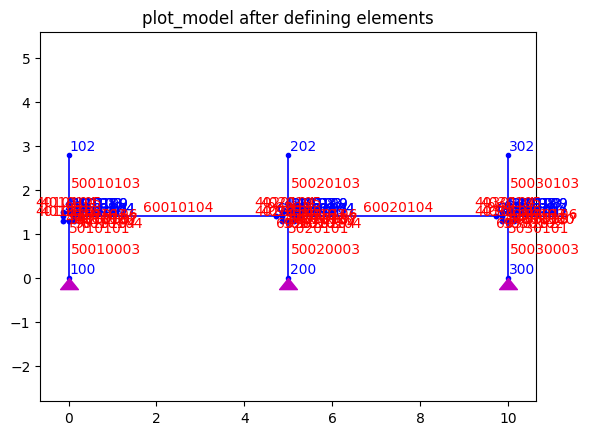

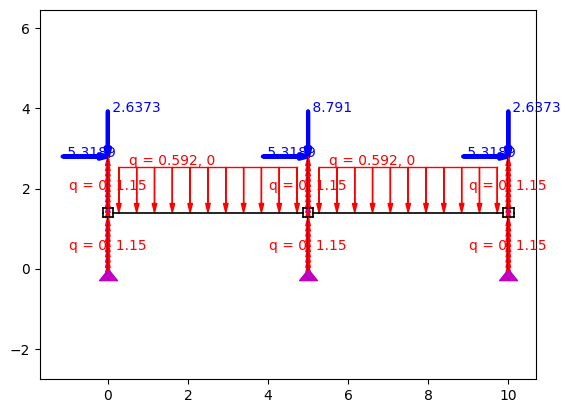

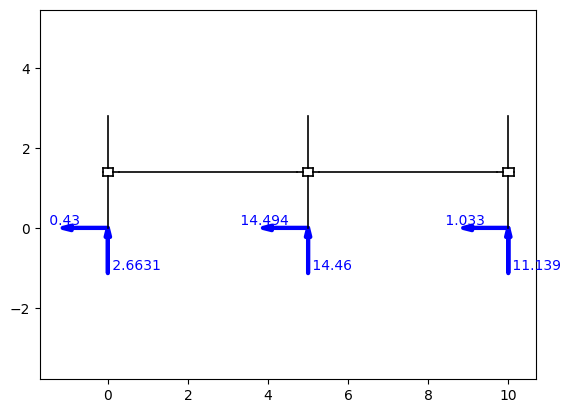

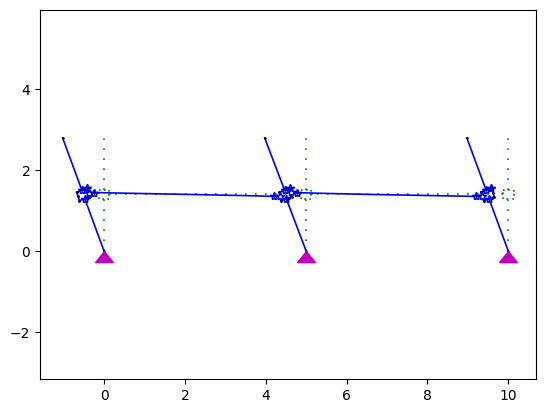

In [33]:
ops.printModel()
opsv.plot_model()
plt.title('plot_model after defining elements')
opsv.plot_load()
opsv.plot_reactions()
# sfac = 80.
opsv.plot_defo()
# opsv.plot_defo(sfac)
# fmt_interp = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
# opsv.plot_defo(sfac, fmt_interp=fmt_interp)
plt.show()

In [34]:
for n in ops.getNodeTags():
    rx, ry, rz = ops.nodeReaction(n)
    print(f"Node {n} reactions: FX={rx:.3f}, FY={ry:.3f}, MZ={rz:.3f}")
    rx, ry, rz = ops.nodeDisp(n)
    print(f"Node {n} disp: dX={rx:.3f}, dY={ry:.3f}, dZ={rz:.3f}")

Node 100 reactions: FX=-0.430, FY=2.663, MZ=0.000
Node 100 disp: dX=0.000, dY=0.000, dZ=0.043
Node 102 reactions: FX=-0.000, FY=-0.000, MZ=0.000
Node 102 disp: dX=-0.121, dY=-0.000, dZ=0.043
Node 200 reactions: FX=-14.494, FY=14.460, MZ=0.000
Node 200 disp: dX=0.000, dY=0.000, dZ=0.045
Node 202 reactions: FX=-0.000, FY=0.000, MZ=0.000
Node 202 disp: dX=-0.121, dY=-0.000, dZ=0.045
Node 300 reactions: FX=-1.033, FY=11.139, MZ=-0.000
Node 300 disp: dX=0.000, dY=0.000, dZ=0.043
Node 302 reactions: FX=0.000, FY=0.000, MZ=0.000
Node 302 disp: dX=-0.121, dY=-0.000, dZ=0.043
Node 410101 reactions: FX=-0.430, FY=1.175, MZ=-0.000
Node 410101 disp: dX=-0.056, dY=-0.000, dZ=0.043
Node 410102 reactions: FX=0.000, FY=0.000, MZ=0.000
Node 410102 disp: dX=-0.060, dY=-0.006, dZ=0.040
Node 410103 reactions: FX=5.319, FY=-4.126, MZ=0.000
Node 410103 disp: dX=-0.064, dY=-0.000, dZ=0.043
Node 410104 reactions: FX=-4.892, FY=2.951, MZ=-0.000
Node 410104 disp: dX=-0.060, dY=0.006, dZ=0.040
Node 410105 reacti

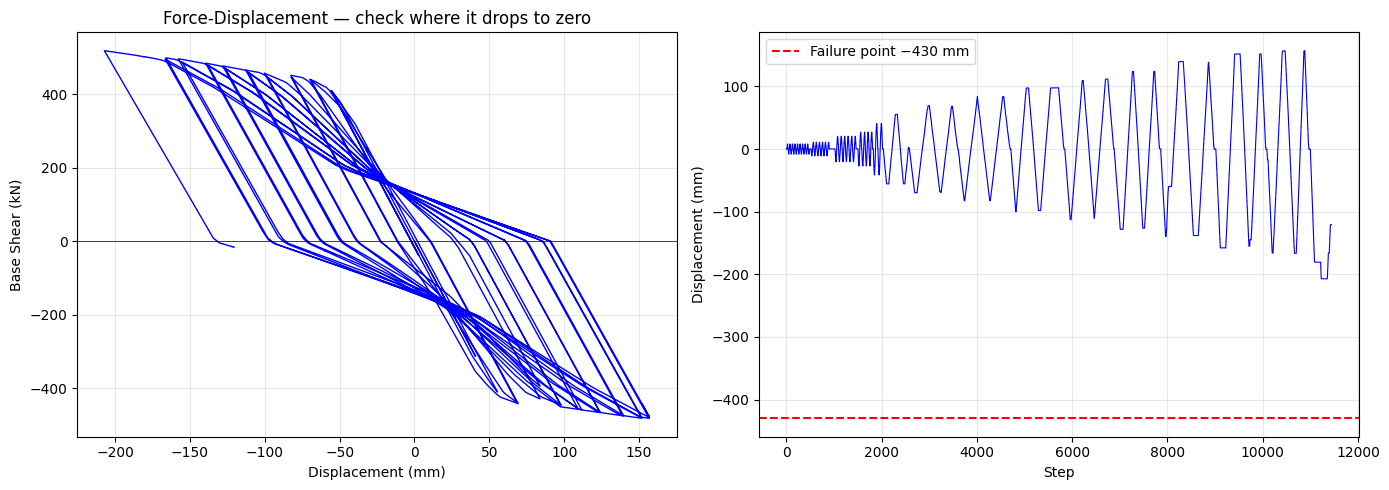

Base shear drops below 10% of peak at step 0
Displacement at that point: 0.0 mm
Peak base shear: 519.1 kN
Final displacement reached: -120.6 mm


In [35]:
#######CONTROL PANEL 
# Load your recorded results - adjust filenames to yours
disp = np.loadtxt(os.path.join(SubPath,'ControlNodedisp.txt'))   # step, DOF1, DOF2...
R100 = np.loadtxt(os.path.join(SubPath,'R100.txt'))
R200 = np.loadtxt(os.path.join(SubPath,'R200.txt'))
R300 = np.loadtxt(os.path.join(SubPath,'R300.txt'))
base_shear = R100[:, 0] + R200[:, 0] + R300[:, 0]

# Control node displacement (column 1 = first DOF after step counter)
d = disp   # metres if model is in m
F = base_shear  # kN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(d * 1000, F, 'b-', lw=1)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('Displacement (mm)')
axes[0].set_ylabel('Base Shear (kN)')
axes[0].set_title('Force-Displacement — check where it drops to zero')
axes[0].grid(True, alpha=0.3)

axes[1].plot(d * 1000, 'b-', lw=0.8)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Displacement (mm)')
axes[1].axhline(-430, color='r', ls='--', label='Failure point −430 mm')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('collapse_diagnosis.png', dpi=150)
plt.show()

# Find the step and displacement where base shear first drops below 10% of peak
peak = np.max(np.abs(F))
collapse_idx = np.where(np.abs(F) < 0.1 * peak)[0]
if len(collapse_idx) > 0:
    print(f"Base shear drops below 10% of peak at step {collapse_idx[0]}")
    print(f"Displacement at that point: {d[collapse_idx[0]]*1000:.1f} mm")
print(f"Peak base shear: {peak:.1f} kN")
print(f"Final displacement reached: {d[-1]*1000:.1f} mm")

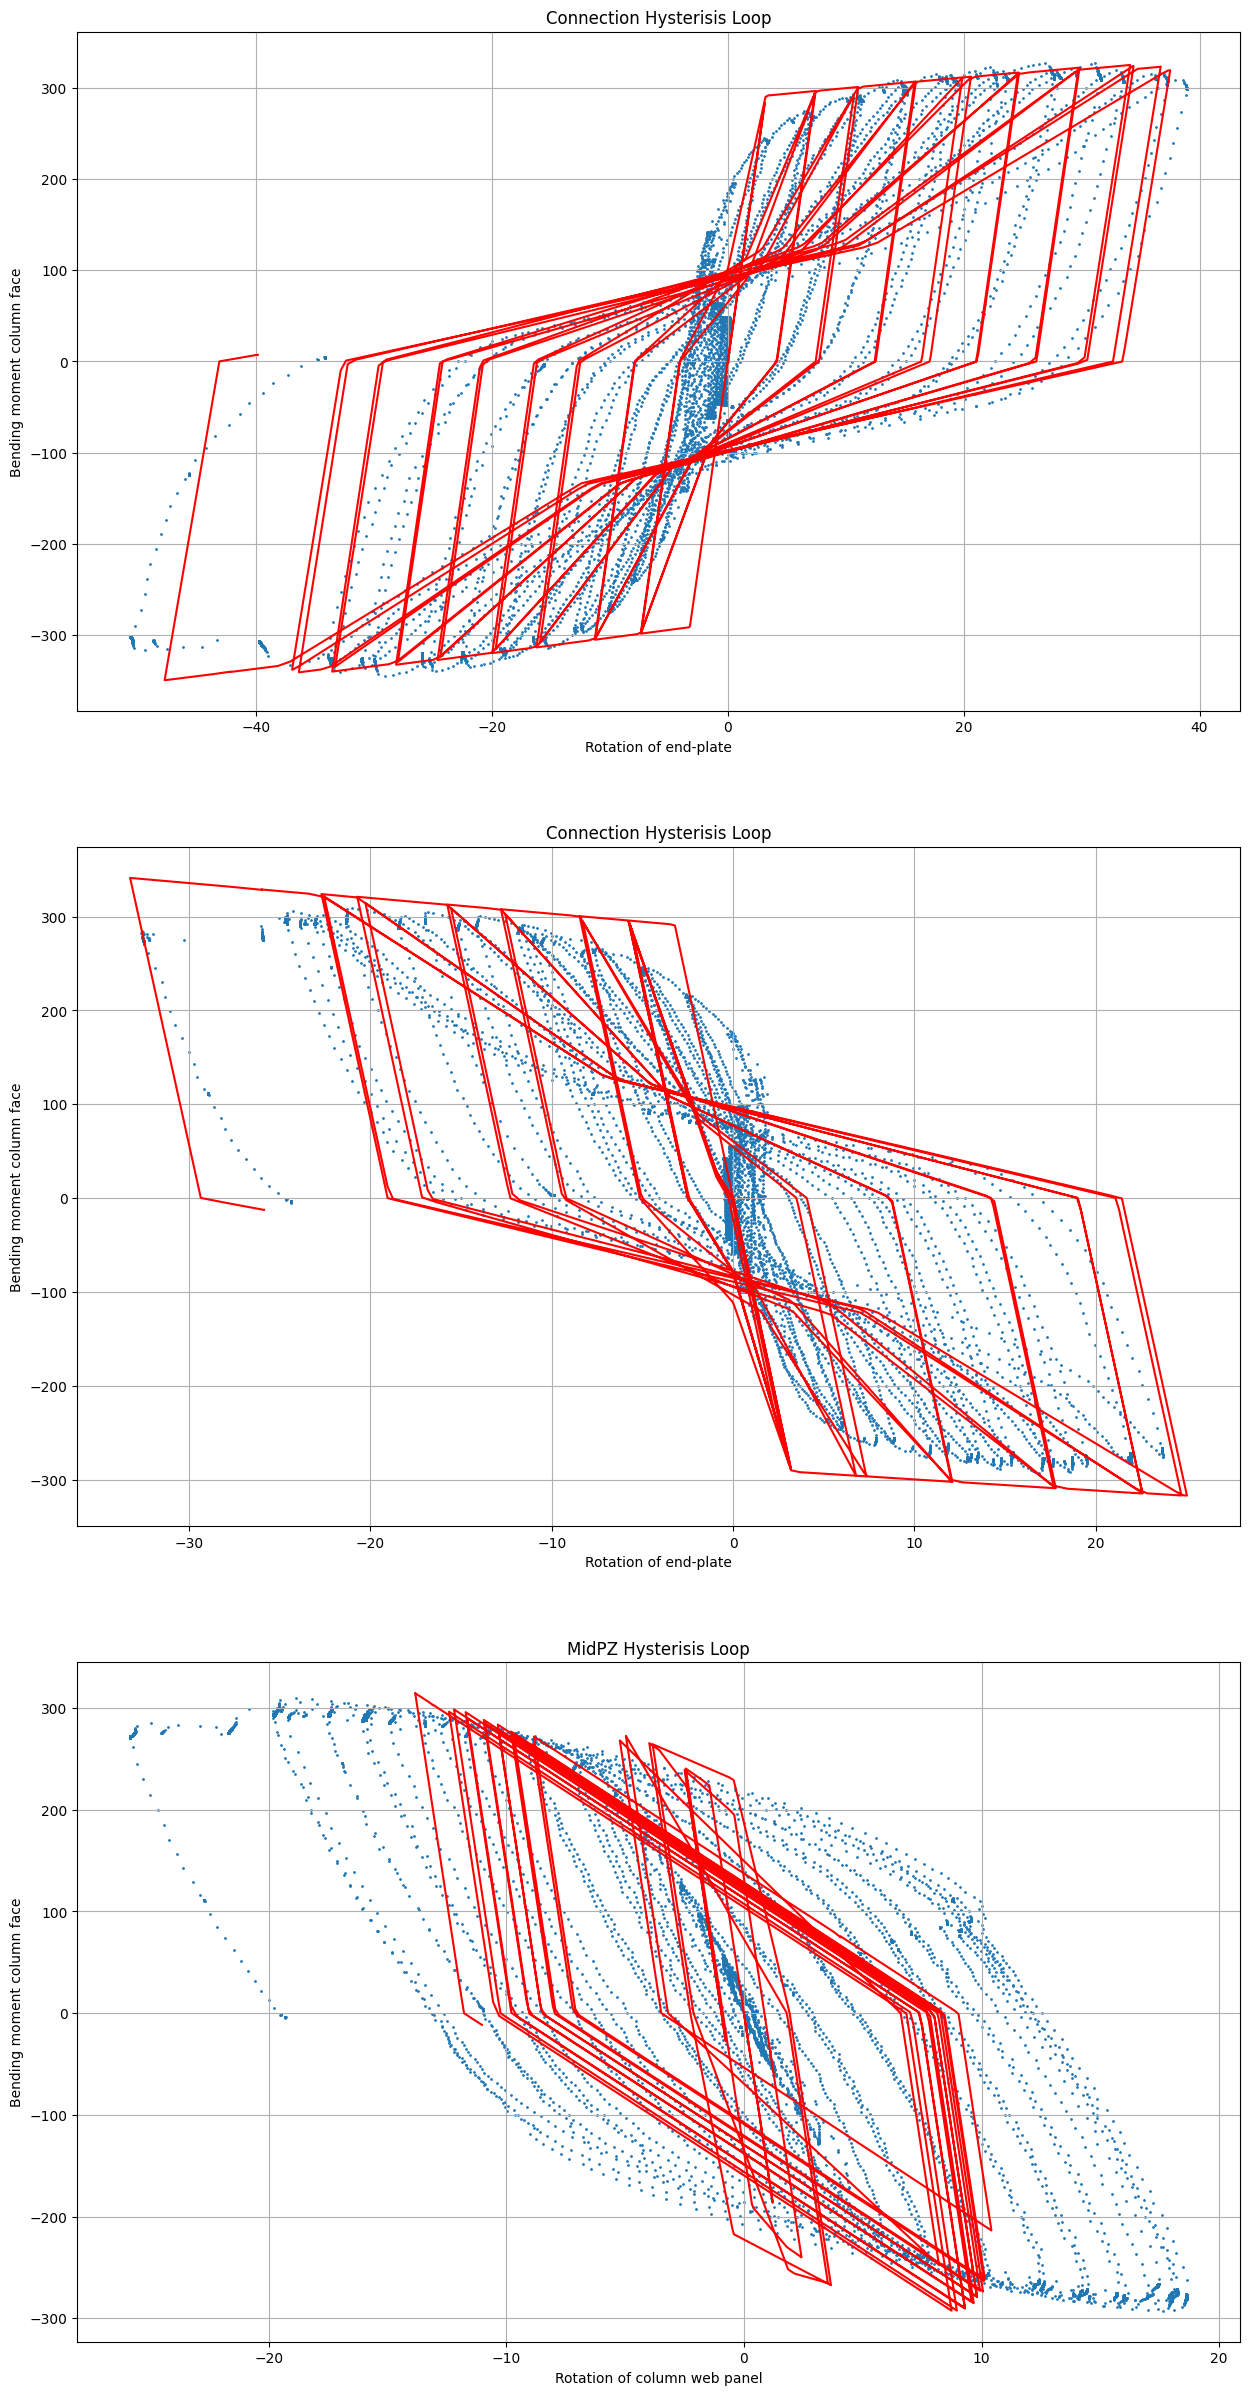

In [36]:
#Control panel 
fig,axes=plt.subplots(3,1,figsize=(15,30))
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['E2'].value
y_label=ws['F2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=5,
    max_col=6,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'9010104moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'9010104thetas.txt')))*1000

axes[0].scatter(x,y, s=1)
axes[0].plot(thetas,-moment,color='r')
axes[0].set_xlabel(x_label)
axes[0].set_ylabel(y_label)
axes[0].set_title('Connection Hysterisis Loop')
axes[0].grid()
#plt.legend()
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['M2'].value
y_label=ws['N2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=13,
    max_col=14,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'9020104moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'9020104thetas.txt')))*1000
axes[1].scatter(x,y, s=1)
axes[1].plot(thetas,moment,color='r')
axes[1].set_xlabel(x_label)
axes[1].set_ylabel(y_label)
axes[1].set_title('Connection Hysterisis Loop')
axes[1].grid()
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['Q2'].value
y_label=ws['R2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=17,
    max_col=18,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'4020100moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'4020100thetas.txt')))*1000
axes[2].scatter(x,y, s=1)
axes[2].plot(0.5*thetas,0.5*moment,color='r')
axes[2].set_xlabel(x_label)
axes[2].set_ylabel(y_label)
axes[2].set_title('MidPZ Hysterisis Loop')
axes[2].grid()
#plt.legend()
plt.savefig('ControlPanel.png', dpi=150)
plt.show()

plt.show()


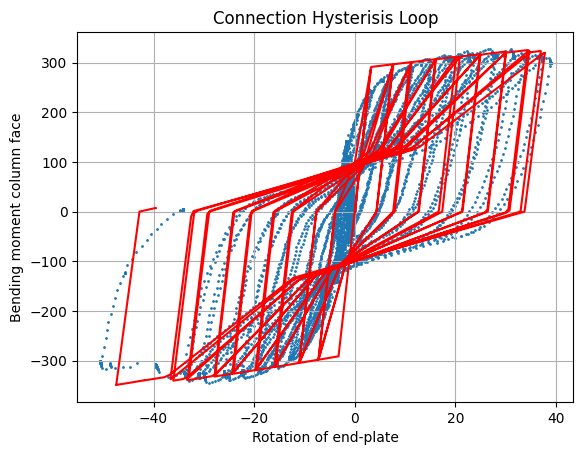

12760


In [37]:
#plt.subplot(3,1)
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['E2'].value
y_label=ws['F2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=5,
    max_col=6,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
import csv


# Save y transposed (as a single row) to CSV
with open('y_transposed.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(y)
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'9030102moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'9030102thetas.txt')))*1000
plt.scatter(x,y, s=1)
plt.plot(thetas,-moment,color='r')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title('Connection Hysterisis Loop')
plt.grid()
#plt.legend()
plt.show()
# Save x as a space-separated single column coords file
with open('x_coords.txt', 'w') as f:
    f.write('\n'.join(str(v) for v in x))
x=np.loadtxt('x_coords.txt')/1000
with open('x_coords.txt', 'w') as f:
    f.write('\n'.join(str(v) for v in x))
print(len(x))


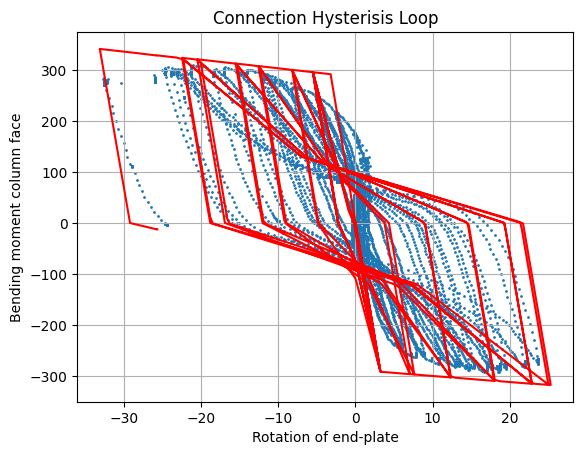

In [38]:
#plt.subplot(3,1)
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['M2'].value
y_label=ws['N2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=13,
    max_col=14,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'9020102moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'9020102thetas.txt')))*1000
plt.scatter(x,y, s=1)
plt.plot(thetas,moment,color='r')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title('Connection Hysterisis Loop')
plt.grid()
#plt.legend()
plt.show()

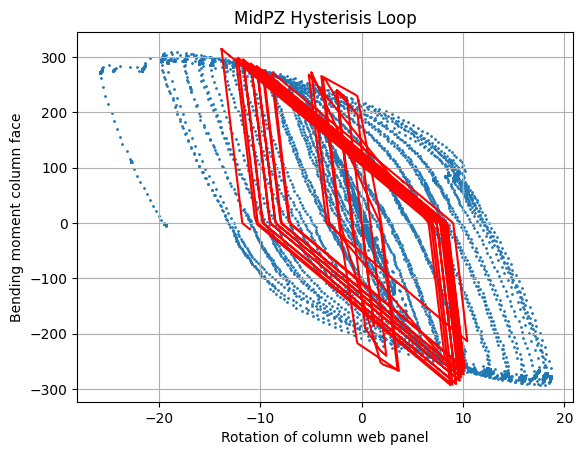

12760
12760


In [39]:
#plt.subplot(3,1)
x = []
y = []
import csv
wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['Q2'].value
y_label=ws['R2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=17,
    max_col=18,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'4020100moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'4020100thetas.txt')))*1000

plt.scatter(x,y, s=1)
plt.plot(0.5*thetas,0.5*moment,color='r')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title('MidPZ Hysterisis Loop')
plt.grid()
#plt.legend()
plt.show()
#Save y transposed (as a single row) to CSV
with open('ypz_transposed.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(y)
# Save x as a space-separated single column coords file
with open('xpz_coords.txt', 'w') as f:
    f.write('\n'.join(str(v) for v in x))
x=np.loadtxt('xpz_coords.txt')/1000
with open('xpz_coords.txt', 'w') as f:
    f.write('\n'.join(str(v) for v in x))
print(len(x))
# Save y transposed (as a single row) to CSV
with open('ypz_transposed.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(y)
# Save x as a space-separated single column coords file
with open('x_coords.txt', 'w') as f:
    f.write('\n'.join(str(v) for v in x))
x=np.loadtxt('x_coords.txt')/1000
with open('x_coords.txt', 'w') as f:
    f.write('\n'.join(str(v) for v in x))
print(len(x))

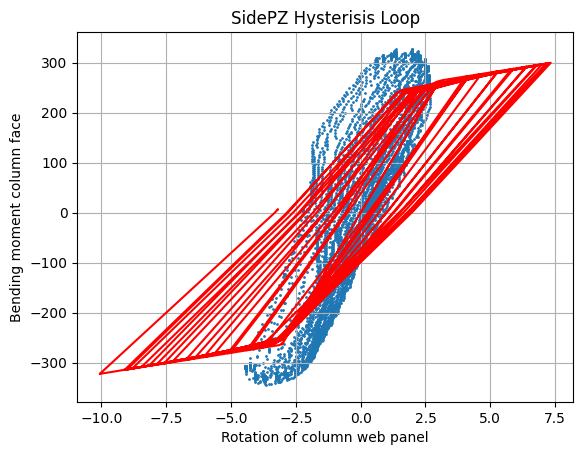

In [40]:
#plt.subplot(3,1)
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['I2'].value
y_label=ws['J2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=9,
    max_col=10,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'4010100moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'4010100thetas.txt')))*1000
plt.scatter(x,y, s=1)
plt.plot(thetas,-moment,color='r')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title('SidePZ Hysterisis Loop')
plt.grid()
#plt.legend()
plt.show()

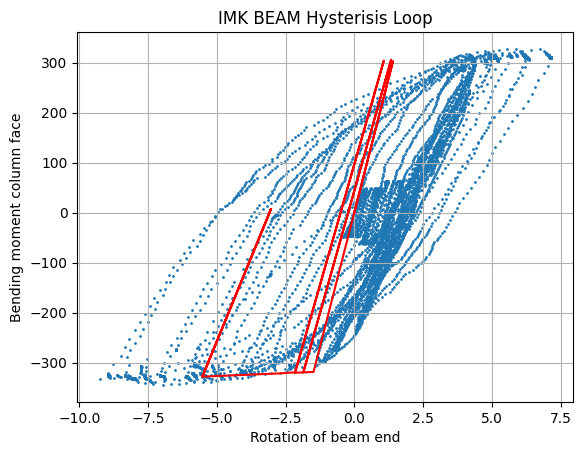

In [41]:
#plt.subplot(3,1)
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['G2'].value
y_label=ws['H2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=7,
    max_col=8,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'6010104moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'6010104thetas.txt')))*1000
plt.scatter(x,y, s=1)
plt.plot(thetas,-moment,color='r')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title('IMK BEAM Hysterisis Loop')
plt.grid()
#plt.legend()
plt.show()

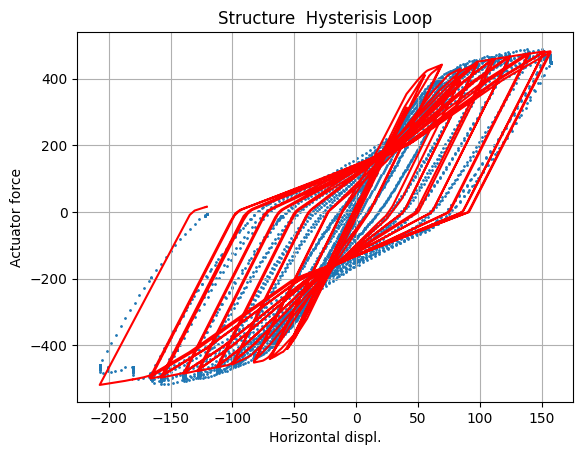

In [42]:
x = []
y = []

wb=load_workbook('SP_S_Experimental_data.xlsx',read_only=True)
ws=wb['S2-C']
data_len=12766#end of data in xlsx file 
data_start=7#beginning of values after discription headers units etc
x_label=ws['A2'].value
y_label=ws['B2'].value

for xval, yval in ws.iter_rows(
    min_row=data_start,
    max_row=data_len,
    min_col=1,
    max_col=2,
    values_only=True
):
    try:
        x.append(float(xval))
        y.append(float(yval))
    except (TypeError, ValueError):
        continue
moment=np.loadtxt(os.path.join(os.path.join(SubPath,'4020100moment.txt')))
thetas=np.loadtxt(os.path.join(os.path.join(SubPath,'4020100thetas.txt')))*1000
plt.scatter(x,y, s=1)
plt.plot(d*1000,-F,color='r')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title('Structure  Hysterisis Loop')
plt.grid()
#plt.legend()
plt.show()

In [43]:
pip list 


Package                       Version
----------------------------- --------------
alabaster                     1.0.0
algopy                        0.7.2
alpha-shapes                  1.1.0
anastruct                     1.6.1
annotated-types               0.7.0
ansys-api-dyna                0.4.2
ansys-dpf-core                0.14.2
ansys-tools-path              0.7.3
anyio                         4.9.0
appdirs                       1.4.4
argon2-cffi                   23.1.0
argon2-cffi-bindings          21.2.0
arrow                         1.3.0
asgiref                       3.7.2
asttokens                     3.0.0
async-lru                     2.0.5
attrs                         25.3.0
babel                         2.16.0
backrefs                      6.1
beautifulsoup4                4.13.4
bleach                        6.2.0
bmcs-beam                     0.0.21a0
bmcs-cross-section            0.0.57a0
bmcs-ibvpy                    0.0.30a0
bmcs-matmod                   0.0.9a0
bm

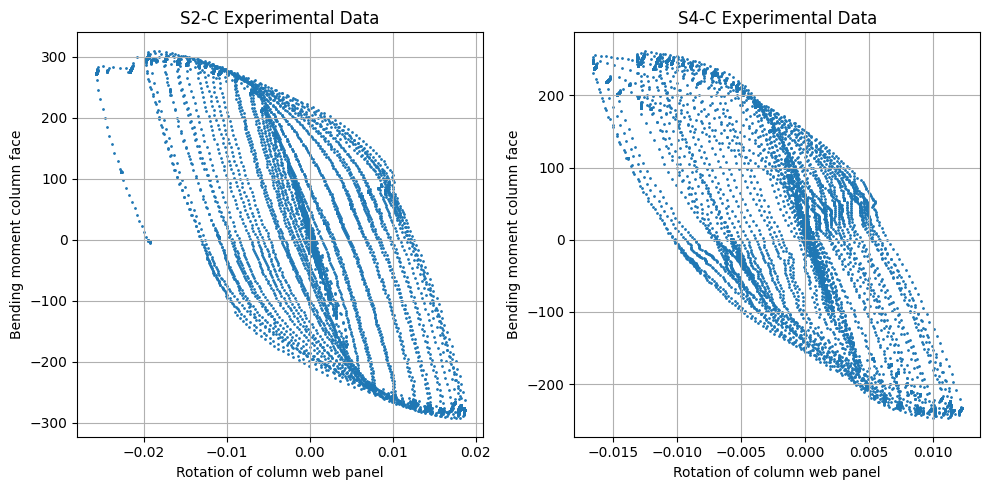

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

def extract(ws, start, end):
    x, y = [], []
    for xv, yv in ws.iter_rows(min_row=start, max_row=end,
                               min_col=17, max_col=18,
                               values_only=True):
        try:
            x.append(float(xv))
            y.append(float(yv))
        except:
            continue
    return np.array(x)/1000, np.array(y)

wb = load_workbook('SP_S_Experimental_data.xlsx', read_only=True)

plt.figure(figsize=(10,5))

for i, sheet in enumerate(['S2-C', 'S4-C'], 1):
    ws = wb[sheet]
    x, y = extract(ws, 7, 14177)

    plt.subplot(1, 2, i)
    plt.scatter(x, y, s=1)

    plt.xlabel(ws['Q2'].value)
    plt.ylabel(ws['R2'].value)
    plt.title(f'{sheet} Experimental Data')
    plt.grid()

plt.tight_layout()
plt.show()

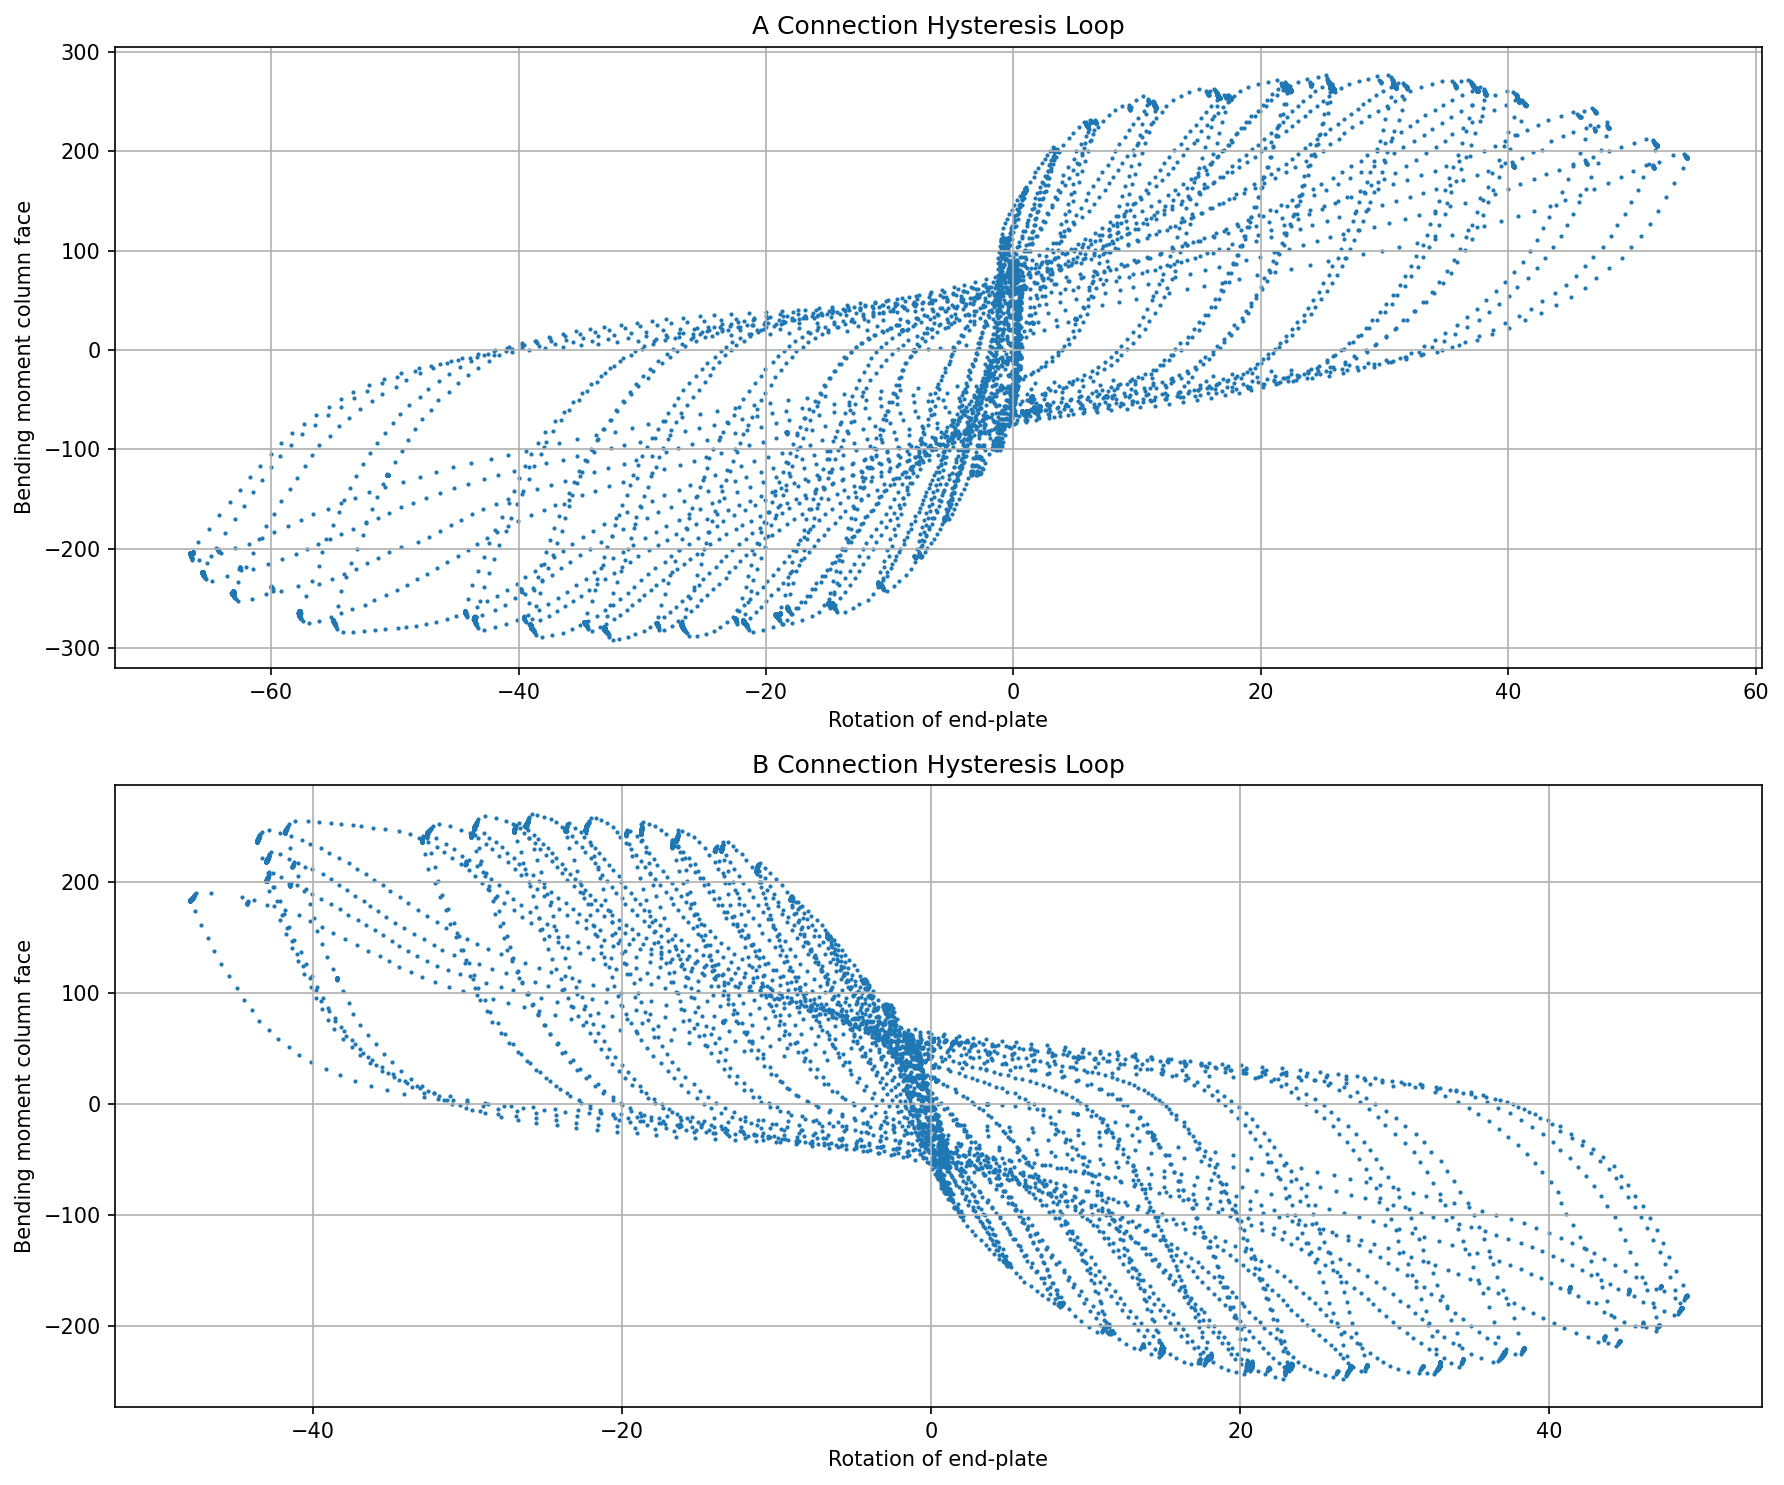

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

wb = load_workbook('SP_S_Experimental_data.xlsx', read_only=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=150)

def extract(ws, start, end, col_x, col_y):
    x, y = [], []

    for xv, yv in ws.iter_rows(
        min_row=start,
        max_row=end,
        min_col=col_x,
        max_col=col_y,
        values_only=True
    ):
        try:
            x.append(float(xv))
            y.append(float(yv))
        except (TypeError, ValueError):
            continue

    return np.array(x), np.array(y)

configs = [
    {"sheet": "S4-C", "xcol": 5,  "ycol": 6,  "xlab": "E2", "ylab": "F2", "title": "A Connection Hysteresis Loop"},
    {"sheet": "S4-C", "xcol": 13, "ycol": 14, "xlab": "M2", "ylab": "N2", "title": "B Connection Hysteresis Loop"},
]

data_start = 7
data_end = 14177

for i, cfg in enumerate(configs):
    ws = wb[cfg["sheet"]]

    x_label = ws[cfg["xlab"]].value
    y_label = ws[cfg["ylab"]].value

    x, y = extract(ws, data_start, data_end, cfg["xcol"], cfg["ycol"])

    axes[i].scatter(x, y, s=1)

    axes[i].set_xlabel(x_label)
    axes[i].set_ylabel(y_label)
    axes[i].set_title(cfg["title"])
    axes[i].grid()

plt.tight_layout()
plt.savefig('ControlPanel.png', dpi=300, bbox_inches='tight')
plt.show()

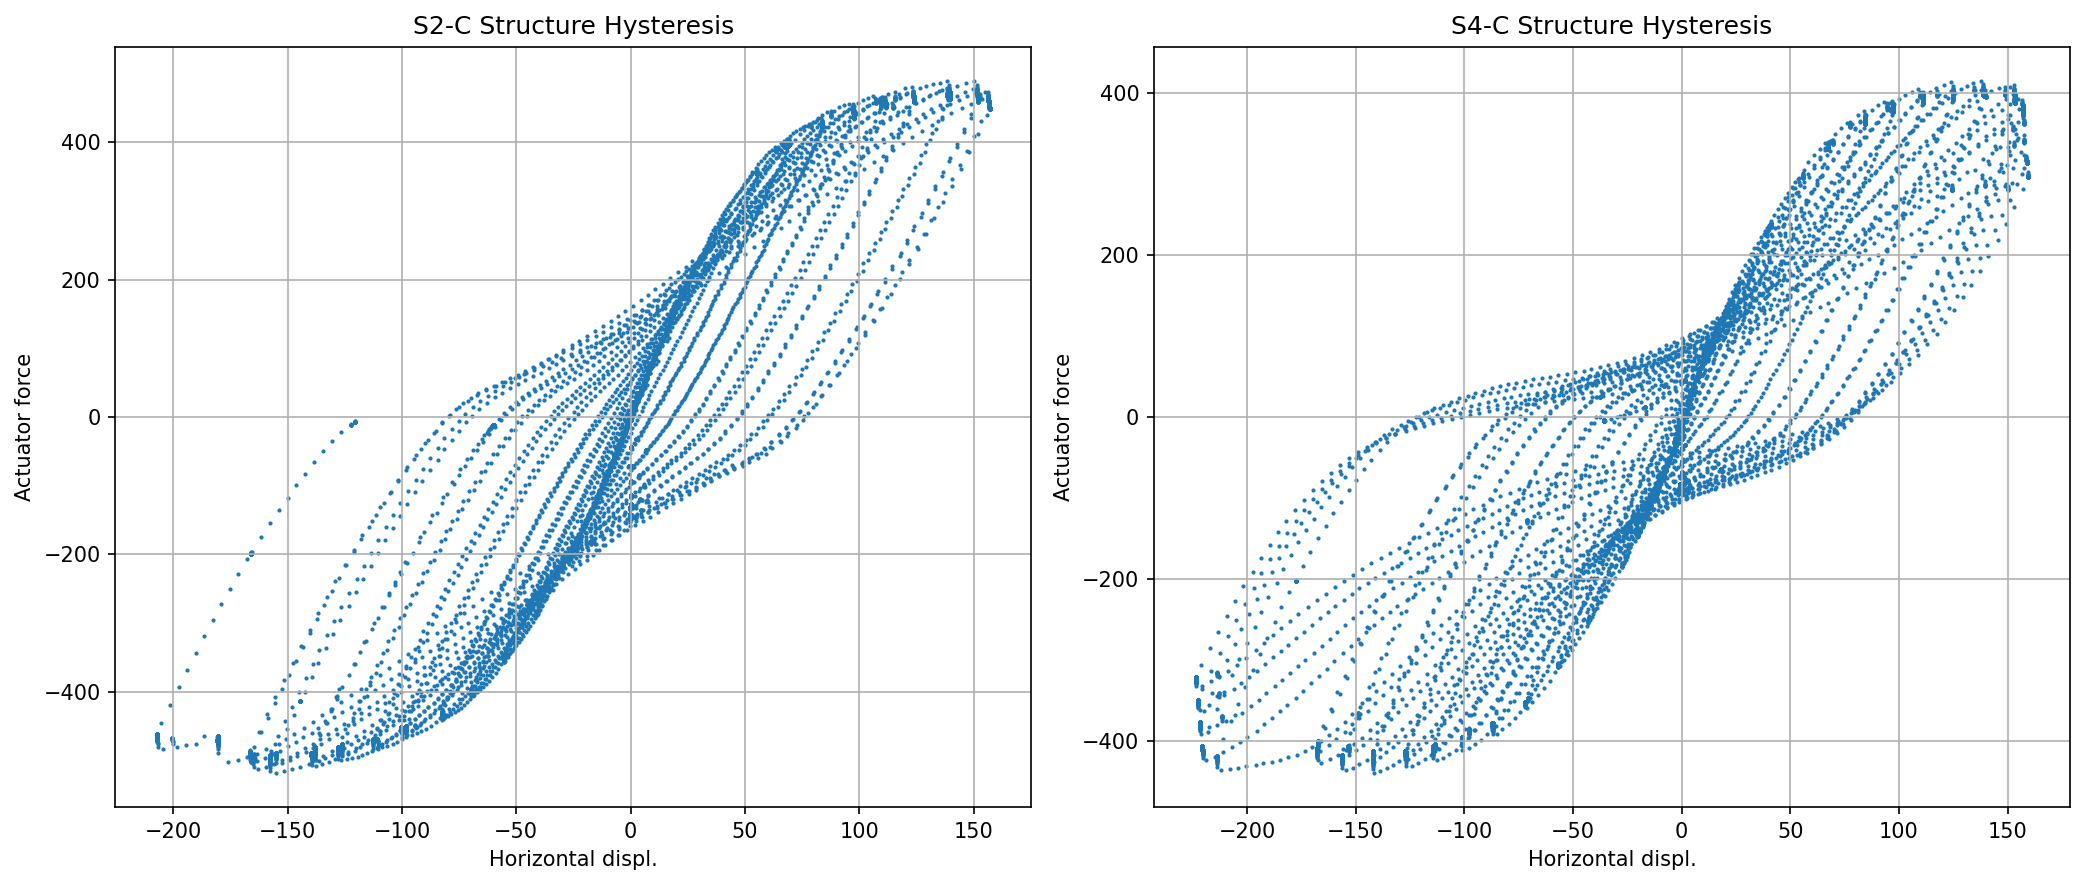

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

def extract(ws, start, end):
    x, y = [], []

    for xv, yv in ws.iter_rows(
        min_row=start,
        max_row=end,
        min_col=1,
        max_col=2,
        values_only=True
    ):
        try:
            x.append(float(xv))
            y.append(float(yv))
        except (TypeError, ValueError):
            continue

    return np.array(x), np.array(y)

wb = load_workbook('SP_S_Experimental_data.xlsx', read_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

configs = [
    {"sheet": "S2-C", "end": 12766},
    {"sheet": "S4-C", "end": 14177},  # <-- your correct length
]

data_start = 7

for i, cfg in enumerate(configs):
    ws = wb[cfg["sheet"]]

    x_label = ws['A2'].value
    y_label = ws['B2'].value

    x, y = extract(ws, data_start, cfg["end"])

    axes[i].scatter(x, y, s=1)

    axes[i].set_xlabel(x_label)
    axes[i].set_ylabel(y_label)
    axes[i].set_title(f'{cfg["sheet"]} Structure Hysteresis')
    axes[i].grid()

plt.tight_layout()
plt.show()